In [1]:
from netCDF4 import Dataset
# from py_eddy_tracker.dataset.grid import RegularGridDataset, UnRegularGridDataset
from datetime import *
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from glob import glob
# from mpl_toolkits.basemap import Basemap
import seawater as sw
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import seaborn as sns
import cmocean as cm
from matplotlib.path import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Plots efficiency and statiscal analysis of Anticyclones and cyclones



In [95]:
def smoo(self,nw):
    import scipy.signal as sg
    win = np.blackman(nw)
    win=win[None,:]*win[:,None]
    peso=sg.fftconvolve(np.ones(self.shape),win,mode='same')
    dataout=sg.fftconvolve(self,win,mode='same')/peso

    return dataout




def geocut(xb,yb,var,ltmn,lnmn,ltmx,lnmx):
    if len(xb.shape)>1:
        indx=np.argwhere((xb[0,:]>=lnmn)&(xb[0,:]<=lnmx)).T[0]
        indy=np.argwhere((yb[:,0]>=ltmn)&(yb[:,0]<=ltmx)).T[0]
        xnew=xb[indy,:][:,indx]
        ynew=yb[indy,:][:,indx]

    else:
        indx=np.argwhere((xb>=lnmn)&(xb<=lnmx)).T[0]
        indy=np.argwhere((yb>=ltmn)&(yb<=ltmx)).T[0]
        xnew=xb[indx]
        ynew=yb[indy]

    varnew=var[indy,:][:,indx]
    return xnew,ynew,varnew


def fig1(sizeh,sizev,lnmn,lnmx,ltmn,ltmx,grid_a=0.01):
    plt.rcParams['font.size']=18
    plt.rcParams['font.sans-serif']='Arial'
    plt.rcParams['font.family'] = "sans-serif"
    plt.rcParams['font.weight']='bold'


    fig = plt.figure(figsize=(sizeh,sizev))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([lnmn, lnmx, ltmn, ltmx], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,edgecolor='#fecf78')
    ax.add_feature(cfeature.LAKES)


    # ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.STATES)


    ax = plt.axes(projection=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True,alpha=grid_a)
    gl.top_labels = False
    gl.right_labels = False

#     plt.show()
    

### Loading data

In [3]:
# var=Dataset('/home/igor/Documents/AntSimi/altdata/clim/sla_climatology.nc')
# lonc,latc=var['longitude'][:]-360,var['latitude'][:];
# slac=var['sla'][:]

dt0=datetime(1950,1,1)
# dt=[dt0 + timedelta(days=np.int(dia)) for dia in var['time']]

'Loading Tracks'
anc=Dataset('/Users/iufarias/Documents/META3.1exp/META3.1exp_DT_allsat_Anticyclonic_long_19930101_20200307.nc')
cnc=Dataset('/Users/iufarias/Documents/META3.1exp/META3.1exp_DT_allsat_Cyclonic_long_19930101_20200307.nc')




### Delimited Area

In [4]:

# dd=pd.read_csv('/home/igor/Documents/AntSimi/data/buffer_200m_6rad.csv')
dd=pd.read_csv('/Users/iufarias/Documents/META3.1exp/bat/buffer_200m_200km.csv')
ddlon,ddlat=np.array(dd['lon']),np.array(dd['lat'])
ddseg=Path(np.array([ddlon,ddlat]).T)


### Bathymetry

In [5]:

ltmn=-29;ltmx=-14;lnmn=-52;lnmx=-35.

topo=Dataset('/Users/iufarias/Documents/META3.1exp/bat/etopo1_bedrock.nc')
xb=topo['lon'][:];yb=topo['lat'][:];zb=topo['Band1'][:];
zb=smoo(zb,20)
xxb,yyb=np.meshgrid(xb,yb);

### Bathymetric Path

In [6]:

c=plt.contourf(xb,yb,zb,levels=[-200,np.inf],colors='k')
plt.close()
segs=[]

for iss in range(len(c.allsegs)):
    # col=c.collections[iss].get_paths()
    col=c.allsegs[iss]

    lens=list(map(len,col))
    indl=np.argmax(lens)
    segs.append(col[indl])

segs=np.vstack(segs);
pseg=Path(segs)


### METAexp original variables

In [7]:

atrack=anc['track'][:]
aobs=anc['observation_number'][:]
alon,alat=anc['longitude'][:],anc['latitude'][:]
atrack=np.int_(atrack.data)
alon=np.where(alon>180,alon-360,alon)
# atrack=pd.Series(atrack.data)
# atrack=atrack.data;

ctrack=cnc['track'][:]
cobs=cnc['observation_number'][:]
clon,clat=cnc['longitude'][:],cnc['latitude'][:]
ctrack=np.int_(ctrack.data)
clon=np.where(clon>180,clon-360,clon)



### Condition 1 - Excluding NH++

In [8]:
condc=(clon>lnmn-10)&(clon<lnmx+10)&(clat>ltmn-10)&(clat<ltmx+10) #esse é o certo
conda=(alon>lnmn-10)&(alon<lnmx+10)&(alat>ltmn-10)&(alat<ltmx+10)


ctrack0=ctrack[condc]
atrack0=atrack[conda]

### Condition 1b - Filtering NH++

In [9]:
xxc=(cobs[condc]==0)
cx1=(clon[condc][xxc]>lnmn)&(clon[condc][xxc]<lnmx)&(clat[condc][xxc]>ltmn)&(clat[condc][xxc]<ltmx)
ics=ctrack0[xxc][cx1] #indices iniciais que precisam ser retirados com  o resto de suas tracks
condc1=np.hstack([np.where(ctrack0==iy)[0] for iy in ics])

ctrack1=ctrack0[condc1]


xxa=(aobs[conda]==0)
ax1=(alon[conda][xxa]>lnmn)&(alon[conda][xxa]<lnmx)&(alat[conda][xxa]>ltmn)&(alat[conda][xxa]<ltmx)
ica=atrack0[xxa][ax1] #indices iniciais que precisam ser retirados com  o resto de suas tracks
conda1=np.hstack([np.where(atrack0==iy)[0] for iy in ica])

atrack1=atrack0[conda1]


###  Condition 2 - Bathtymetry


In [10]:
xxc=(cobs[condc][condc1]==0)
cbol=[pseg.contains_point((clon[condc][condc1][iy],clat[condc][condc1][iy])) for iy in np.where(xxc)[0] ]
icc=ctrack1[xxc][~np.array(cbol)]
condc2=np.hstack([np.where(ctrack1==iy)[0] for iy in icc])

ctrack2=ctrack1[condc2]

xxa=(aobs[conda][conda1]==0)
abol=[pseg.contains_point((alon[conda][conda1][iy],alat[conda][conda1][iy])) for iy in np.where(xxa)[0] ]
ica=atrack1[xxa][~np.array(abol)]
conda2=np.hstack([np.where(atrack1==iy)[0] for iy in ica])

atrack2=atrack1[conda2]


### Condition 3 - Buffer zone

In [11]:
xxc=(cobs[condc][condc1][condc2]==0)
cbol=[ddseg.contains_point((clon[condc][condc1][condc2][iy],clat[condc][condc1][condc2][iy])) for iy in np.where(xxc)[0] ]
icc=ctrack2[xxc][np.array(cbol)]
condc3=np.hstack([np.where(ctrack2==iy)[0] for iy in icc])

ctrack3=ctrack2[condc3]

xxa=(aobs[conda][conda1][conda2]==0)
abol=[ddseg.contains_point((alon[conda][conda1][conda2][iy],alat[conda][conda1][conda2][iy])) for iy in np.where(xxa)[0] ]
ica=atrack2[xxa][np.array(abol)]
conda3=np.hstack([np.where(atrack2==iy)[0] for iy in ica])

atrack3=atrack2[conda3]


### Saving files and removing redundancies

In [12]:

pd.Series.to_pickle(atrack3,'/Users/iufarias/Documents/META3.1exp/backups/atrack_final.pkl')
pd.Series.to_pickle(ctrack3,'/Users/iufarias/Documents/META3.1exp/backups/ctrack_final.pkl')

atrack=atrack3.copy()
ctrack=ctrack3.copy()
del atrack3,atrack1,atrack2,ctrack3,ctrack1,ctrack2

### Unique values and final conditions



In [13]:
aunik=np.unique(atrack)
cunik=np.unique(ctrack)

### Snapshot Tracked

In [15]:

ref=cnc['time'][:][condc][condc1][condc2][condc3][0]
at=np.int_((anc['time'][:][conda][conda1][conda2][conda3]-ref))
ct=np.int_((cnc['time'][:][condc][condc1][condc2][condc3]-ref))

## Anticyclone Parameters

In [16]:
Atime=anc['time'][:][conda][conda1][conda2][conda3].data
Aamp=pd.Series(anc['amplitude'][:][conda][conda1][conda2][conda3]);Aamp=Aamp.groupby(atrack).mean();
Avel=pd.Series(anc['speed_average'][:][conda][conda1][conda2][conda3]);Avel=Avel.groupby(atrack).mean();
Avelmax=pd.Series(anc['speed_average'][:][conda][conda1][conda2][conda3]);Avelmax=Avelmax.groupby(atrack).max();
Arad=pd.Series(anc['effective_radius'][:][conda][conda1][conda2][conda3]);Arad=Arad.groupby(atrack).mean();
alon=alon[conda][conda1][conda2][conda3];
alat=alat[conda][conda1][conda2][conda3];
# AyContour=pd.DataFrame(anc['effective_contour_latitude'][:]);
# AxContour=pd.DataFrame(anc['effective_contour_longitude'][:])-360;
Aobs=aobs[conda][conda1][conda2][conda3]

Aeke=0.5*((Avel*100)**2)


Adist=[];Adur=[];Apvel=[];Apvel2=[];Apvel3=[];
Adate=[];Afdate=[];

iii=0
for ai in aunik:
# for ai in np.unique(atrack):
# for ai in range(atrack.max()+1):
#     print('{0}%'.format((iii/len(aunik))*100),end='\r')
    iii+=1

    #duration
    dur=len(atrack[atrack==ai])
    #distance
    distx=sw.dist(lon=alon[atrack==ai],lat=alat[atrack==ai])[0]
    disty=sw.dist(lon=[alon[atrack==ai][0],alon[atrack==ai][-1]],
                    lat=[alat[atrack==ai][0],alat[atrack==ai][-1]])[0]
    # distz=sw.dist(lon=[AxContour.iloc[atrack==ai,:].mean(1).iloc[0],AxContour.iloc[atrack==ai,:].mean(1).iloc[-1]],
    #                 lat=[AyContour.iloc[atrack==ai,:].mean(1).iloc[0],AyContour.iloc[atrack==ai,:].mean(1).iloc[-1]])[0]


    k=np.insert(distx,0,0)
    dist=np.cumsum(k)
    #propagation speed
    pvel=(dist[-1]*1e3)/(dur*86400)
    pvel2=(disty[0]*1e3/(dur*86400))
    # pvel3=(distz[0]*1e3/(dur*86400))
    #time
    time=Atime[atrack==ai];

    date=dt0+ timedelta(days=np.int(time.mean()));
    fdate=dt0 + timedelta(days=np.int(time[0]));

    #Concatenating
    
    # Adist.append(dist[-1]);
    Adist.append(disty[0]);

    Adur.append(dur);
    Apvel.append(pvel*100);
    Apvel2.append(pvel2*100);
    # Apvel3.append(pvel3*100);
    Adate.append(date);
    Afdate.append(fdate);

Adist=np.array(Adist);
Adur=np.array(Adur);
Apvel=np.array(Apvel);
Apvel2=np.array(Apvel2);
# Apvel3=np.array(Apvel3);

<ipython-input-16-7da229d7b2e5>:44: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  date=dt0+ timedelta(days=np.int(time.mean()));
<ipython-input-16-7da229d7b2e5>:45: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in Num

## Cyclone Parameters

In [17]:
'Cyclonic parameters'
Ctime=cnc['time'][:][condc][condc1][condc2][condc3].data
Camp=pd.Series(cnc['amplitude'][:][condc][condc1][condc2][condc3]);Camp=Camp.groupby(ctrack).mean();
Cvel=pd.Series(cnc['speed_average'][:][condc][condc1][condc2][condc3]);Cvel=Cvel.groupby(ctrack).mean();
Cvelmax=pd.Series(cnc['speed_average'][:][condc][condc1][condc2][condc3]);Cvelmax=Cvelmax.groupby(ctrack).max();
Crad=pd.Series(cnc['effective_radius'][:][condc][condc1][condc2][condc3]);Crad=Crad.groupby(ctrack).mean();
clon=clon[condc][condc1][condc2][condc3]
clat=clat[condc][condc1][condc2][condc3]
# CyContour=pd.DataFrame(cnc['effective_contour_latitude'][:]);
# CxContour=pd.DataFrame(cnc['effective_contour_longitude'][:])-360;

Cobs=cobs[condc][condc1][condc2][condc3]
Ceke=0.5*((Cvel*100)**2)

# Camp=Camp[1:]
# Cvel=Cvel[1:]
# Crad=Crad[1:]
# Ceke=Ceke[1:]

Cdist=[];Cdur=[];Cpvel=[];Cpvel2=[];Cpvel3=[];
Cdate=[];Cfdate=[];


iii=0
for ci in cunik:
# for ci in range(ctrack.max()+1):
# for ci in np.unique(ctrack):

#     print('{0}%'.format((iii/len(cunik))*100),end='\r')
    iii+=1
    dur=len(ctrack[ctrack==ci])

    distx=sw.dist(lon=clon[ctrack==ci],lat=clat[ctrack==ci])[0]
    disty=sw.dist(lon=[clon[ctrack==ci][0],clon[ctrack==ci][-1]],
                    lat=[clat[ctrack==ci][0],clat[ctrack==ci][-1]])[0]
    # distz=sw.dist(lon=[CxContour.iloc[ctrack==ci,:].mean(1).iloc[0],CxContour.iloc[ctrack==ci,:].mean(1).iloc[-1]],
                    # lat=[CyContour.iloc[ctrack==ci,:].mean(1).iloc[0],CyContour.iloc[ctrack==ci,:].mean(1).iloc[-1]])[0]




    k=np.insert(distx,0,0)
    dist=np.cumsum(k)

    pvel=(dist[-1]*1e3)/(dur*86400)
    pvel2=(disty[0]*1e3/(dur*86400))
    # pvel3=(distz[0]*1e3/(dur*86400))

    time=Ctime[ctrack==ci];

    date=dt0+ timedelta(days=np.int(time.mean()));
    fdate=dt0 + timedelta(days=np.int(time[0]));

    # Cdist.append(dist[-1]);
    Cdist.append(disty[0])
    Cdur.append(dur);
    Cpvel.append(pvel*100);
    Cpvel2.append(pvel2*100);
    # Cpvel3.append(pvel3*100);
    Cdate.append(date);
    Cfdate.append(fdate);


Cdist=np.array(Cdist)
Cdur=np.array(Cdur)
Cpvel=np.array(Cpvel)
Cpvel2=np.array(Cpvel2)
# Cpvel3=np.array(Cpvel3)



<ipython-input-17-8322e002ca42>:51: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  date=dt0+ timedelta(days=np.int(time.mean()));
<ipython-input-17-8322e002ca42>:52: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in Num

In [18]:

#Contratining/Filtering by amplitude and radius
vamp=0 #cm
vrad=0 #km

#masks 
# ccond=(Camp>=vamp/100)&(Crad>=vrad*1e3) # m2cm / m2km
# acond=(Aamp>=vamp/100)&(Arad>=vrad*1e3)

ccond=(Camp==Camp) # m2cm / m2km
acond=(Aamp==Aamp)



### Plot the daily images with detections



In [19]:

# # for ip in range(slac.shape[0]):
# for ip in range(365):
#     p=plt.figure(figsize=(4.5 , 4.5))
#     plt.contourf(lonc,latc,slac[ip],cmap='seismic',levels=np.linspace(-0.2,0.2,50))
#     plt.contour(lonc,latc,slac[ip],colors='dimgray',linewidths=0.5,levels=np.linspace(-0.2,0.2,30))


#     # asx=np.unique(atrack[at==ip])
#     # for yi in asx[asx>0]:
#     #     if yi in aunik:
#     #         plt.plot(alon[atrack==yi],alat[atrack==yi],color='IndianRed',marker='o',markersize=3)
#     #         plt.text(alon[atrack==yi],alat[atrack==yi],np.int(yi),color='IndianRed',fontweight='bold')


#     # csx=np.unique(ctrack[ct==ip])
#     # for yi in csx[csx>0]:
#     #     if yi in cunik:
#     #         plt.plot(clon[ctrack==yi][0],clat[ctrack==yi][0],color='navy',marker='o',markersize=3)
#     #         plt.text(clon[ctrack==yi][0],clat[ctrack==yi][0],np.int(yi),color='navy',fontweight='bold')

#     [plt.plot(xll,yll,'ro',markersize=3) for xll,yll in zip(alon[at==ip][atrack[at==ip]>0],alat[at==ip][atrack[at==ip]>0]) ]
#     [plt.text(xll,yll,np.int(tll),color='r',fontweight='bold') for xll,yll,tll in zip(alon[at==ip][atrack[at==ip]>0],alat[at==ip][atrack[at==ip]>0],atrack[at==ip][atrack[at==ip]>0]) ]

#     [plt.plot(xll,yll,'bo',markersize=3) for xll,yll in zip(clon[ct==ip][ctrack[ct==ip]>0],clat[ct==ip][ctrack[ct==ip]>0]) ]
#     [plt.text(xll,yll,np.int(tll),color='b',fontweight='bold') for xll,yll,tll in zip(clon[ct==ip][ctrack[ct==ip]>0],clat[ct==ip][ctrack[ct==ip]>0],ctrack[ct==ip][ctrack[ct==ip]>0]) ]
    
#     plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-200,np.inf])
#     plt.contourf(xxb,yyb,zb,colors='green',alpha=1,levels=[0,np.inf])

#     plt.ylim(-22,-14)
#     plt.xlim(-41,-33)

#     # plt.tight_layout()
#     plt.savefig('/home/igor/Documents/META_eddy_detection/maps/{0:04d}_track.png'.format(ip+1))
#     plt.close()

### Plotting Eddy Formation

### Setting cartopy template map

In [20]:
ltmn=-29;ltmx=-14;lnmn=-52;lnmx=-35.
fig1(sizeh=10.26,sizev=8.96,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)

plt.scatter(alon[Aobs==0],alat[Aobs==0],alpha=0.5,s=4,color='r')
# [plt.plot(alon[atrack==iy],alat[atrack==iy],'r',linewidth=0.5) for iy in range(atrack.max())]
# [plt.plot(alon[atrack==iy][0],alat[atrack==iy][0],'r.',markersize=5,alpha=0.5) for iy in aunik[acond]]

plt.scatter(clon[Cobs==0],clat[Cobs==0],alpha=0.5,s=4,color='b')
# # [C.plot(clon[ctrack==iy],clat[ctrack==iy],'b',linewidth=0.5) for iy in range(ctrack.max())]
# # [C.plot(clon[ctrack==iy][0],clat[ctrack==iy][0],'b.',markersize=5,alpha=0.5) for iy in cunik[ccond]]

plt.contourf(xb,yb,zb,levels=[-200,0],alpha=0.8,colors='dimgray')

cq=plt.contour(xb,yb,zb,levels=[-200,0],colors='k')   
# plt.clabel(cq,fmt='%.d')
plt.plot(ddlon,ddlat,'k--',zorder=-1)



# plt.tight_layout()
plt.savefig('/Users/iufarias/Documents/META3.1exp/figs/formation_points.png')
plt.close()

<ipython-input-2-021d8b9917ed>:50: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())


### Plotting Eddy Dissipation

In [21]:
fig1(sizeh=10.26,sizev=8.96,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


# [C.plot(alon[atrack==iy],alat[atrack==iy],'r',linewidth=0.5) for iy in range(atrack.max())]
[plt.plot(alon[atrack==iy][-1],alat[atrack==iy][-1],'r.',markersize=5,alpha=0.5) for iy in aunik[acond]]

# [C.plot(clon[ctrack==iy],clat[ctrack==iy],'b',linewidth=0.5) for iy in range(ctrack.max())]
[plt.plot(clon[ctrack==iy][-1],clat[ctrack==iy][-1],'b.',markersize=5,alpha=0.5) for iy in cunik[ccond]]

plt.contourf(xb,yb,zb,levels=[-200,0],alpha=0.8,colors='dimgray')

cq=plt.contour(xb,yb,zb,levels=[-200,0],colors='k')   
# plt.clabel(cq,fmt='%.d')

# plt.tight_layout()
plt.savefig('/Users/iufarias/Documents/META3.1exp/figs/dissipation_points.png')
plt.close()

<ipython-input-2-021d8b9917ed>:50: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())


### Saving table of statistics



In [22]:

ctt=pd.Series({'amp':np.nanmean(Camp[ccond]),'amp_min':np.nanmin(Camp[ccond]),'amp_max':np.nanmax(Camp[ccond]),'amp_std':np.nanstd(Camp[ccond]),
                'vel':np.nanmean(Cvel[ccond]),'vel_min':np.nanmin(Cvel[ccond]),'vel_max':np.nanmax(Cvel[ccond]),'vel_std':np.nanstd(Cvel[ccond]),
                'rad':np.nanmean(Crad[ccond]),'rad_min':np.nanmin(Crad[ccond]),'rad_max':np.nanmax(Crad[ccond]),'rad_std':np.nanstd(Crad[ccond]),
                'eke':np.nanmean(Ceke[ccond]),'eke_min':np.nanmin(Ceke[ccond]),'eke_max':np.nanmax(Ceke[ccond]),'eke_std':np.nanstd(Ceke[ccond]),
                'dist':np.nanmean(Cdist[ccond]),'dist_min':np.nanmin(Cdist[ccond]),'dist_max':np.nanmax(Cdist[ccond]),'dist_std':np.nanstd(Cdist[ccond]),
                'dur':np.nanmean(Cdur[ccond]),'dur_min':np.nanmin(Cdur[ccond]),'dur_max':np.nanmax(Cdur[ccond]),'dur_std':np.nanstd(Cdur[ccond]),
                'pvel':np.nanmean(Cpvel[ccond]),'pvel_min':np.nanmin(Cpvel[ccond]),'pvel_max':np.nanmax(Cpvel[ccond]),'pvel_std':np.nanstd(Cpvel[ccond]),
                'pvel2':np.nanmean(Cpvel2[ccond]),'pvel2_min':np.nanmin(Cpvel2[ccond]),'pvel2_max':np.nanmax(Cpvel2[ccond]),'pvel2_std':np.nanstd(Cpvel2[ccond])})
                # 'pvel3':np.nanmean(Cpvel3[ccond]),'pvel2_min':np.nanmin(Cpvel3[ccond]),'pvel3_max':np.nanmax(Cpvel3[ccond]),'pvel3_std':np.nanstd(Cpvel3[ccond])})


att=pd.Series({'amp':np.nanmean(Aamp[acond]),'amp_min':np.nanmin(Aamp[acond]),'amp_max':np.nanmax(Aamp[acond]),'amp_std':np.nanstd(Aamp[acond]),
                'vel':np.nanmean(Avel[acond]),'vel_min':np.nanmin(Avel[acond]),'vel_max':np.nanmax(Avel[acond]),'vel_std':np.nanstd(Avel[acond]),
                'rad':np.nanmean(Arad[acond]),'rad_min':np.nanmin(Arad[acond]),'rad_max':np.nanmax(Arad[acond]),'rad_std':np.nanstd(Arad[acond]),
                'eke':np.nanmean(Aeke[acond]),'eke_min':np.nanmin(Aeke[acond]),'eke_max':np.nanmax(Aeke[acond]),'eke_std':np.nanstd(Aeke[acond]),
                'dist':np.nanmean(Adist[acond]),'dist_min':np.nanmin(Adist[acond]),'dist_max':np.nanmax(Adist[acond]),'dist_std':np.nanstd(Adist[acond]),
                'dur':np.nanmean(Adur[acond]),'dur_min':np.nanmin(Adur[acond]),'dur_max':np.nanmax(Adur[acond]),'dur_std':np.nanstd(Adur[acond]),
                'pvel':np.nanmean(Apvel[acond]),'pvel_min':np.nanmin(Apvel[acond]),'pvel_max':np.nanmax(Apvel[acond]),'pvel_std':np.nanstd(Apvel[acond]),
                'pvel2':np.nanmean(Apvel2[acond]),'pvel2_min':np.nanmin(Apvel2[acond]),'pvel2_max':np.nanmax(Apvel2[acond]),'pvel2_std':np.nanstd(Apvel2[acond])})
                # 'pvel3':np.nanmean(Apvel3[acond]),'pvel3_min':np.nanmin(Apvel3[acond]),'pvel3_max':np.nanmax(Apvel3[acond]),'pvel3_std':np.nanstd(Apvel3[acond])})



savep='/Users/iufarias/Documents/META3.1exp/figs/'
ctt.to_csv(savep+ 'cyclone_prop.dat',sep='\t',mode='w',float_format='%.6f',index=True,header=True,na_rep='NaN')
att.to_csv(savep + 'anticyclone_prop.dat',sep='\t',mode='w',float_format='%.6f',index=True,header=True,na_rep='NaN')


In [23]:
print('Number of Eddies: {0}'.format(aunik[acond].shape[0] + cunik[ccond].shape[0]))



print('Number of AC: {0}'.format(aunik[acond].shape[0]))
anumber=aunik[acond].shape[0]

print('Number of CC: {0}'.format(cunik[ccond].shape[0]))
cnumber=cunik[ccond].shape[0]


Number of Eddies: 2187
Number of AC: 1192
Number of CC: 995


### Figure 1a & 1b - Regression Plots


#### CC

<ipython-input-25-664e76dc5c54>:134: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


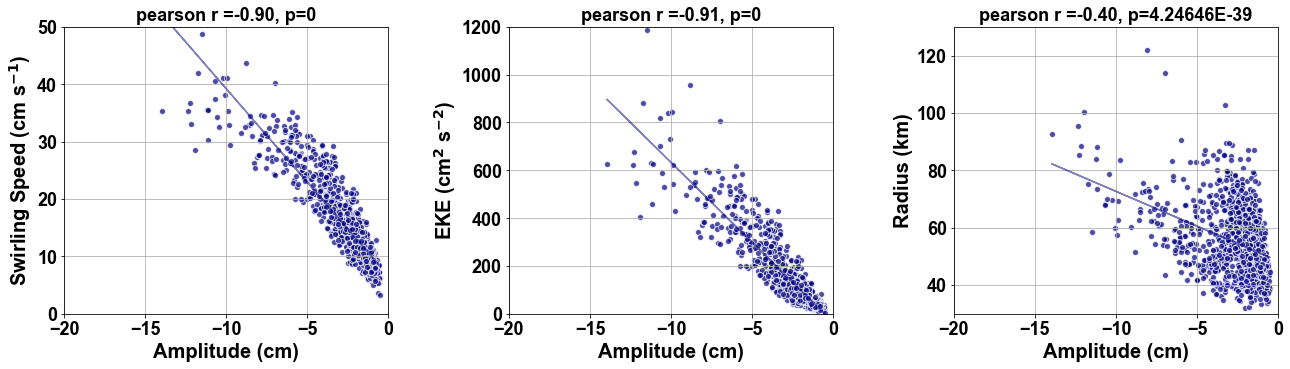

In [25]:

Wc=Crad/1e3

colorx='navy'
fsz=20;

pc=plt.figure(figsize=(18.53,  5.46))

gs = gridspec.GridSpec(1,14)
ax1 = plt.subplot(gs[0, 0:4])

Xc,Yc=-Camp*100,Cvel*100
# X=Xc[Xc<=-1];Y=Yc[Xc<=-1];
X=Xc[(Xc<=-vamp)&(Wc>=vrad)];Y=Yc[(Xc<=-vamp)&(Wc>=vrad)];


slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
line = slope*(X)+intercept

plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
plt.plot(X,line,color=colorx,alpha=0.5)

# textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
#                     'p value ={0}'.format(p_value)))
                    
textstr = ('pearson r ={:.2f}, p={:G}'.format(r_value,p_value))


plt.title(textstr,fontweight='bold',fontsize=fsz-2)

plt.grid()

plt.ylabel(r'Swirling Speed (cm s$^{-1}$)',fontsize=fsz, fontweight='bold')
plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
plt.ylim(0,50)
plt.xlim(-20,0)



ax2 = plt.subplot(gs[0, 5:9])

Xc,Yc=-Camp*100,Ceke
# X=Xc[Xc<=-1];Y=Yc[Xc<=-1];
X=Xc[(Xc<=-vamp)&(Wc>=vrad)];Y=Yc[(Xc<=-vamp)&(Wc>=vrad)];

slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
line = slope*(X)+intercept

plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
plt.plot(X,line,color=colorx,alpha=0.5)

# textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
#                     'p value ={0}'.format(p_value)))
                    
textstr = ('pearson r ={:.2f}, p={:G}'.format(r_value,p_value))

plt.title(textstr,fontweight='bold',fontsize=fsz-2)
plt.grid()

plt.ylabel(r'EKE (cm$^2$ s$^{-2}$)',fontsize=fsz, fontweight='bold')
plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
plt.ylim(0,1200)
plt.xlim(-20,0)


ax3 = plt.subplot(gs[0, 10:14])

Xc,Yc=-Camp*100, Crad/1e3
# X=Xc[Xc<=-1];Y=Yc[Xc<=-1];
# X=Xc[(Xc<=-1 )&( Yc>=40)];Y=Yc[(Xc<=-1 )&(Yc>=40)];
X=Xc[(Xc<=-vamp)&(Wc>=vrad)];Y=Yc[(Xc<=-vamp)&(Wc>=vrad)];




slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
line = slope*(X)+intercept

plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
plt.plot(X,line,color=colorx,alpha=0.5)

# textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
#                     'p value ={0}'.format(p_value)))
                    
textstr = ('pearson r ={:.2f}, p={:G}'.format(r_value,p_value))



# plt.text(X.min(),Y.max()-0.5,textstr)
plt.title(textstr,fontweight='bold',fontsize=fsz-2)
plt.grid()

plt.ylabel(r'Radius (km)',fontsize=fsz, fontweight='bold')
plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
plt.ylim(30,130)
plt.xlim(-20,0)


# ax4 = plt.subplot(gs[0,15:19])

# xxc=-Camp*100
# Xc,Yc=-Crad/1e3, Cpvel3
# # X=Xc[Xc<=-1];Y=Yc[Xc<=-1];
# X=Xc[(xxc<=-vamp)&(Wc>=vrad)];Y=Yc[(xxc<=-vamp)&(Wc>=vrad)];



# slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
# line = slope*(X)+intercept

# plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
# plt.plot(X,line,color=colorx,alpha=0.5)

# # textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
# #                     'p value ={0}'.format(p_value)))
                    
# textstr = ('pearson r ={:.2f}'.format(r_value))


# # plt.text(X.min(),Y.max()-0.5,textstr)
# plt.title(textstr,fontweight='bold',fontsize=fsz-2)
# plt.grid()

# plt.ylabel(r'Propagating Speed (cm $s^{-1}$)',fontsize=fsz, fontweight='bold')
# plt.xlabel('Radius (km)',fontsize=fsz, fontweight='bold')
# plt.ylim(0,30)
# plt.xlim(-150,-30)

pc.subplots_adjust(top=0.9,
bottom=0.17,
left=0.06,
right=0.97,
hspace=0.21,
wspace=0.55)
plt.tight_layout()

# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Scatter_Cyclone.png')
# plt.close()


#### AC

<ipython-input-26-70c1db442e94>:145: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


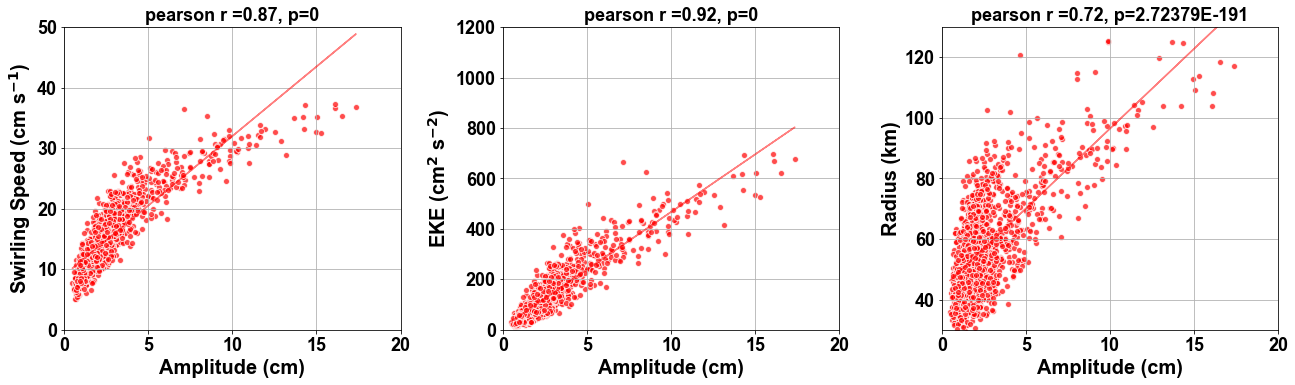

In [26]:

Wc=Arad/1e3
colorx='red'
fsz=20;

pc=plt.figure(figsize=(18.53,  5.46))



gs = gridspec.GridSpec(1,14)
ax1 = plt.subplot(gs[0, 0:4])

Xc,Yc=Aamp*100,Avel*100

# X=Xc[Xc>=1];Y=Yc[Xc>=1];
# X=Xc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];Y=Yc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];
X=Xc[(Xc>=vamp)&(Wc>=vrad)];Y=Yc[(Xc>=vamp)&(Wc>=vrad)];

slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
line = slope*(X)+intercept

plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
plt.plot(X,line,color=colorx,alpha=0.5)

# textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
#                     'p value ={0}'.format(p_value)))
                    
textstr = ('pearson r ={:.2f}, p={:G}'.format(r_value,p_value))



# plt.text(X.min(),Y.max()-0.5,textstr)
plt.title(textstr,fontweight='bold',fontsize=fsz-2)
plt.grid()

plt.ylabel(r'Swirling Speed (cm s$^{-1}$)',fontsize=fsz, fontweight='bold')
plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
plt.ylim(0,50)
plt.xlim(0,20)



ax2 = plt.subplot(gs[0, 5:9])

Xc,Yc=Aamp*100, Aeke
# X=Xc[Xc>=1];Y=Yc[Xc>=1];
# X=Xc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];Y=Yc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];
X=Xc[(Xc>=vamp)&(Wc>=vrad)];Y=Yc[(Xc>=vamp)&(Wc>=vrad)];


slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
line = slope*(X)+intercept

plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
plt.plot(X,line,color=colorx,alpha=0.5)

# textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
#                     'p value ={0}'.format(p_value)))
                    
textstr = ('pearson r ={:.2f}, p={:G}'.format(r_value,p_value))



# plt.text(X.min(),Y.max()-0.5,textstr)
plt.title(textstr,fontweight='bold',fontsize=fsz-2)
plt.grid()

plt.ylabel(r'EKE (cm$^2$ s$^{-2}$)',fontsize=fsz, fontweight='bold')
plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
plt.ylim(0,1200)
plt.xlim(0,20)


ax3 = plt.subplot(gs[0, 10:14])

Xc,Yc=Aamp*100, Arad/1e3

# X=Xc[Xc>=1];Y=Yc[Xc>=1];
# X=Xc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];Y=Yc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];
X=Xc[(Xc>=vamp)&(Wc>=vrad)];Y=Yc[(Xc>=vamp)&(Wc>=vrad)];



slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
line = slope*(X)+intercept

plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
plt.plot(X,line,color=colorx,alpha=0.5)

# textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
#                     'p value ={0}'.format(p_value)))
                    
textstr = ('pearson r ={:.2f}, p={:G}'.format(r_value,p_value))



# plt.text(X.min(),Y.max()-0.5,textstr)
plt.title(textstr,fontweight='bold',fontsize=fsz-2)
plt.grid()

plt.ylabel(r'Radius (km)',fontsize=fsz, fontweight='bold')
plt.xlabel('Amplitude (cm)',fontsize=fsz, fontweight='bold')
plt.ylim(30,130)
plt.xlim(0,20)


# ax4 = plt.subplot(gs[0,15:19])

# xxc=Aamp*100
# Xc,Yc=Arad/1e3,Apvel3;
# # X=Xc[Xc>=1];Y=Yc[Xc>=1];
# X=Xc[(xxc>=vamp)&(Wc>=vrad)];Y=Yc[(xxc>=vamp)&(Wc>=vrad)];

# # X=Xc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];Y=Yc[Xc>=np.nanmean(Xc)-np.nanstd(Xc)];




# slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
# line = slope*(X)+intercept

# plt.scatter(X,Y,c=colorx,edgecolors='white',linewidths=1,alpha=0.7)
# plt.plot(X,line,color=colorx,alpha=0.5)

# # textstr = '\n'.join(('pearson r ={:.2f}'.format(r_value),
# #                     'p value ={0}'.format(p_value)))
                    
# textstr = ('pearson r ={:.2f}'.format(r_value))


# # plt.text(X.min(),Y.max()-0.5,textstr)
# plt.title(textstr,fontweight='bold',fontsize=fsz-2)
# plt.grid()

# plt.ylabel(r'Propagating Speed (cm $s^{-1}$)',fontsize=fsz, fontweight='bold')
# plt.xlabel('Radius (km)',fontsize=fsz, fontweight='bold')
# plt.ylim(0,30)
# plt.xlim(vrad,150)

pc.subplots_adjust(top=0.88,
bottom=0.11,
left=0.06,
right=0.97,
hspace=0.2,
wspace=0.2)
plt.tight_layout()

# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Scatter_AntiCyclone.png')
# plt.close()

### Figura 2 - Histogramas

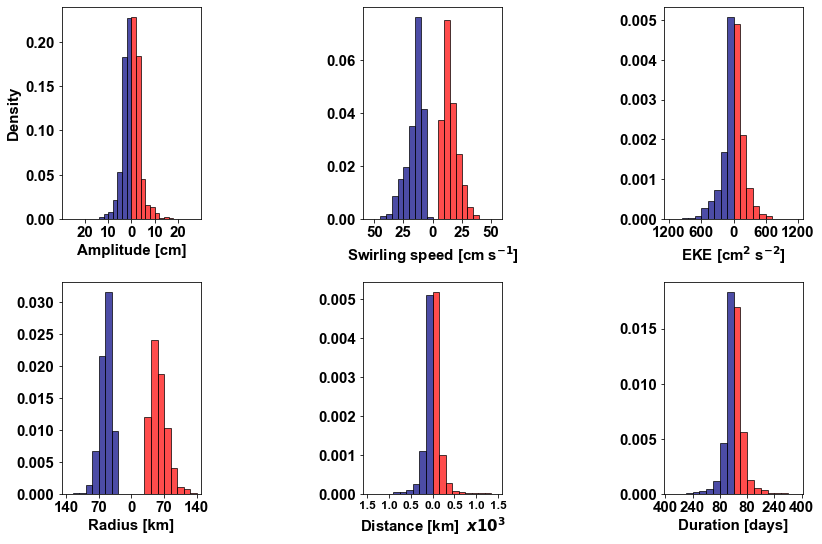

In [27]:

dbol=True

Ra=Arad/1e3;
Rc=Crad/1e3;

plt.rcParams['font.weight']='bold'
plt.rcParams['font.size']=15
p=plt.figure(figsize=(11.66,  7.81))

gs = gridspec.GridSpec(6,8)
ax1 = plt.subplot(gs[0:3, 0:2])

Hc=-Camp*100
# cH=Hc.copy()[Hc<-1]
cH=Hc.copy()#[(Hc<=-vamp)&(Rc>=40)]

# cH=Hc.copy()[Hc<np.nanmean(Hc)+np.nanstd(Hc)]


Ha=Aamp*100
# AA=Ah[Ha>1]
aH=Ha.copy()#[(Ha>=vamp)&(Ra>=40)]
# aH=Ha.copy()[Ha>np.nanmean(Ha) -np.nanstd(Ha)]

binx=np.linspace(-20,20,21)
biny=np.linspace(-20,20,5)

plt.hist(cH,binx,edgecolor='k',color='navy',alpha=0.7,density=dbol)
plt.hist(aH,binx,edgecolor='k',color='red',alpha=0.7,density=dbol)


if dbol:
    plt.ylabel('Density',fontweight='bold')
else:
    plt.ylabel('Number of eddies',fontweight='bold')

plt.xlabel('Amplitude [cm]',fontweight='bold')


plt.xticks(biny,np.int_(np.abs(biny)))

plt.xlim(-30,30)



ax2 = plt.subplot(gs[0:3, 3:5])

Ch=-Cvel*100
# CC=Ch[Hc<-1]
CC=Ch.copy()#[(Hc<=-vamp)&(Rc>=40)]

# CC=Ch[Hc<np.nanmean(Hc)+np.nanstd(Hc)]



Ah=Avel*100
# AA=Ah[Ha>1]
AA=Ah.copy()#[(Ha>=vamp)&(Ra>=40)]

binx=np.linspace(-50,50,21)
biny=np.arange(-50,50+25,25)

# AA=Ah[Ha>np.nanmean(Ha) -np.nanstd(Ha)]

plt.hist(CC,binx,edgecolor='k',color='navy',alpha=0.7,density=dbol)
plt.hist(AA,binx,edgecolor='k',color='red',alpha=0.7,density=dbol)
# plt.ylabel('Number of eddies',fontweight='bold')
plt.xlabel(r'Swirling speed [cm s$^{-1}$]',fontweight='bold')

plt.xticks(biny,np.int_(np.abs(biny)))
plt.xlim(-60,60)

ax3 = plt.subplot(gs[0:3, 6:8])

Ch=-Ceke
# CC=Ch[Hc<-1]
CC=Ch.copy()#[(Hc<=-vamp)&(Rc>=40)]

# CC=Ch[Hc<np.nanmean(Hc)+np.nanstd(Hc)]


Ah=Aeke
# AA=Ah[Ha>1]
AA=Ah.copy()#[(Ha>=vamp)&(Ra>=40)]

# AA=Ah[Ha>np.nanmean(Ha) -np.nanstd(Ha)]

binx=np.linspace(-1200,1200,21)
biny=np.arange(-1200,1200+600,600)

plt.hist(CC,binx,edgecolor='k',color='navy',alpha=0.7,density=dbol)
plt.hist(AA,binx,edgecolor='k',color='red',alpha=0.7,density=dbol)
# plt.ylabel('Number of eddies',fontweight='bold')
plt.xlabel('EKE [cm$^{2}$ s$^{-2}$]',fontweight='bold')

plt.xticks(biny,np.int_(np.abs(biny)))
plt.xlim(-1300,1300)


ax4 = plt.subplot(gs[3:6, 0:2])

Ch=-Crad/1e3
# CC=Ch[Hc<-1]
CC=Ch.copy()#[(Hc<=-vamp)&(Rc>=40)]

# CC=Ch[Hc<np.nanmean(Hc)+np.nanstd(Hc)]


Ah=Arad/1e3
# AA=Ah[Ha>1]
AA=Ah.copy()#[(Ha>=vamp)&(Ra>=40)]

# AA=Ah[Ha>np.nanmean(Ha) -np.nanstd(Ha)]
binx=np.linspace(-140,140,21)
biny=np.arange(-140,140+70,70)

plt.hist(CC,binx,edgecolor='k',color='navy',alpha=0.7,density=dbol)
plt.hist(AA,binx,edgecolor='k',color='red',alpha=0.7,density=dbol)
# plt.ylabel('Number of eddies',fontweight='bold')
plt.xlabel('Radius [km]',fontweight='bold')

plt.xticks(biny,np.int_(np.abs(biny)))
plt.xlim(-150,150)


ax5 = plt.subplot(gs[3:6, 3:5])


# Ch=-Cpvel3
# # CC=Ch[Hc<-1]
# CC=Ch.copy()[(Hc<=-vamp)&(Rc>=40)]

# # CC=Ch[Hc<np.nanmean(Hc)+np.nanstd(Hc)]


# Ah=Apvel3
# # AA=Ah[Ha>1]
# AA=Ah.copy()[(Ha>=vamp)&(Ra>=40)]

# # AA=Ah[Ha>np.nanmean(Ha) -np.nanstd(Ha)]


# plt.hist(CC,10,edgecolor='k',color='navy',alpha=0.7,density=dbol)
# plt.hist(AA,10,edgecolor='k',color='red',alpha=0.7,density=dbol)


# if dbol:
#     plt.ylabel('Density',fontweight='bold')
# else:
#     plt.ylabel('Number of eddies',fontweight='bold')
# plt.xlabel(r'Propagating speed [cm s$^{-1}$]',fontweight='bold')

# plt.xticks(np.linspace(-25,25,5),np.int_(np.abs(np.linspace(-25,25,5))))


# plt.xlim(-25,25)




Ch=-Cdist
# CC=Ch[Hc<-1]
CC=Ch.copy()#[(Hc<=-vamp)&(Rc>=40)]

# CC=Ch[Hc<np.nanmean(Hc)+np.nanstd(Hc)]


Ah=Adist
# AA=Ah[Ha>1]
AA=Ah.copy()#[(Ha>=vamp)&(Ra>=40)]

# AA=Ah[Ha>np.nanmean(Ha) -np.nanstd(Ha)]
binx=np.linspace(-1500,1500,21)
biny=np.arange(-1500,2000,500)

plt.hist(CC,binx,edgecolor='k',color='navy',alpha=0.7,density=dbol)
plt.hist(AA,binx,edgecolor='k',color='red',alpha=0.7,density=dbol)
# plt.ylabel('Number of eddies',fontweight='bold')
plt.xlabel('Distance [km]  $x10^{3}$',fontweight='bold')


plt.xticks(biny,(np.abs(biny/1e3)),fontsize=12)

plt.xlim(-1600,1600)

ax6 = plt.subplot(gs[3:6, 6:8])



Ch=-Cdur
# CC=Ch[Hc<-1]
CC=Ch.copy()#[(Hc<=-vamp)&(Rc>=40)]

# CC=Ch[Hc<np.nanmean(Hc)+np.nanstd(Hc)]


Ah=Adur
# AA=Ah[Ha>1]
AA=Ah.copy()#[(Ha>=vamp)&(Ra>=40)]

# AA=Ah[Ha>np.nanmean(Ha) -np.nanstd(Ha)]

binx=np.linspace(-400,400,21)
biny=np.arange(-400,400+160,160)

plt.hist(CC,binx,edgecolor='k',color='navy',alpha=0.7,density=dbol)
plt.hist(AA,binx,edgecolor='k',color='red',alpha=0.7,density=dbol)
# plt.ylabel('Number of eddies',fontweight='bold')
plt.xlabel('Duration [days]',fontweight='bold')

plt.xticks(biny,np.int_(np.abs(biny)))
plt.xlim(-410,410)


plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_histogram.png')
# plt.close()



### Figura 2bb - CDFs

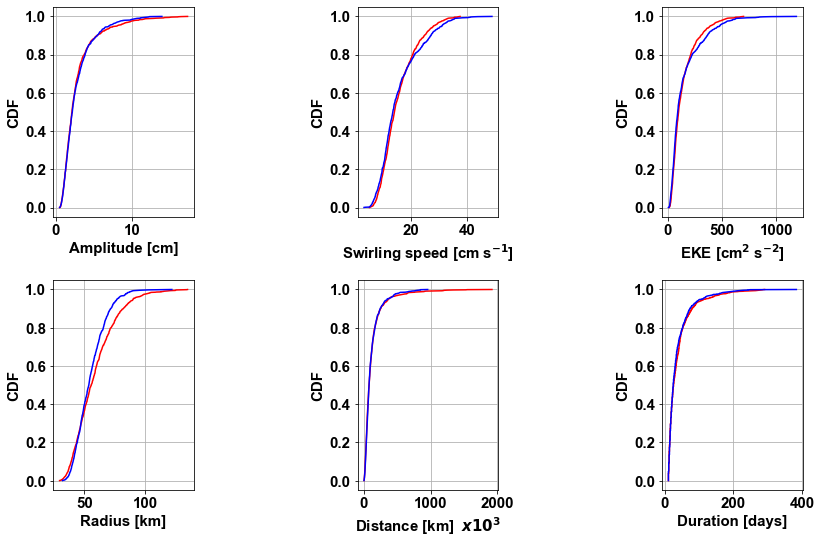

In [28]:

def ecdf(data):
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n+1) / float(n)
    return x, y


plt.rcParams['font.weight']='bold'
plt.rcParams['font.size']=15
p=plt.figure(figsize=(11.66,  7.81))

gs = gridspec.GridSpec(6,8)
ax1 = plt.subplot(gs[0:3, 0:2])

Hc=Camp*100
cH=ecdf(Hc)

Ha=Aamp*100
aH=ecdf(Ha)

plt.plot(aH[0],aH[1],c='r')
plt.plot(cH[0],cH[1],c='b')
plt.grid()

plt.ylabel('CDF',fontweight='bold')
plt.xlabel('Amplitude [cm]',fontweight='bold')



ax2 = plt.subplot(gs[0:3, 3:5])

Ch=Cvel*100
CC=ecdf(Ch)#[(Hc<=-vamp)&(Rc>=40)]


Ah=Avel*100
AA=ecdf(Ah)#[(Ha>=vamp)&(Ra>=40)]

plt.plot(AA[0],AA[1],c='r')
plt.plot(CC[0],CC[1],c='b')
plt.grid()

plt.ylabel('CDF',fontweight='bold')
plt.xlabel(r'Swirling speed [cm s$^{-1}$]',fontweight='bold')


ax3 = plt.subplot(gs[0:3, 6:8])

Ch=Ceke
CC=ecdf(Ch)#[(Hc<=-vamp)&(Rc>=40)]


Ah=Aeke
AA=ecdf(Ah)#[(Ha>=vamp)&(Ra>=40)]

plt.plot(AA[0],AA[1],c='r')
plt.plot(CC[0],CC[1],c='b')
plt.grid()

plt.ylabel('CDF',fontweight='bold')
plt.xlabel('EKE [cm$^{2}$ s$^{-2}$]',fontweight='bold')


ax4 = plt.subplot(gs[3:6, 0:2])

Ch=Crad/1e3
CC=ecdf(Ch)#[(Hc<=-vamp)&(Rc>=40)]

Ah=Arad/1e3
AA=ecdf(Ah)#[(Ha>=vamp)&(Ra>=40)]


plt.plot(AA[0],AA[1],c='r')
plt.plot(CC[0],CC[1],c='b')
plt.grid()


plt.ylabel('CDF',fontweight='bold')
plt.xlabel('Radius [km]',fontweight='bold')



ax5 = plt.subplot(gs[3:6, 3:5])



Ch=Cdist
CC=ecdf(Ch)#[(Hc<=-vamp)&(Rc>=40)]

Ah=Adist
AA=ecdf(Ah)#[(Ha>=vamp)&(Ra>=40)]


plt.plot(AA[0],AA[1],c='r')
plt.plot(CC[0],CC[1],c='b')
plt.grid()


plt.ylabel('CDF',fontweight='bold')
plt.xlabel('Distance [km]  $x10^{3}$',fontweight='bold')



ax6 = plt.subplot(gs[3:6, 6:8])



Ch=Cdur
CC=ecdf(Ch)#[(Hc<=-vamp)&(Rc>=40)]

Ah=Adur
AA=ecdf(Ah)#[(Ha>=vamp)&(Ra>=40)]

plt.plot(AA[0],AA[1],c='r')
plt.plot(CC[0],CC[1],c='b')
plt.grid()


plt.ylabel('CDF',fontweight='bold')
plt.xlabel('Duration [days]',fontweight='bold')



plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_CDF.png')
# plt.close()



### Figuras 3a,3b,3c - Boxplots



### Parameters

In [29]:
mostr=[u'Jan', u'Feb', u'Mar', u'Apr',u'May',u'Jun',u'Jul',u'Aug',u'Sep',u'Oct',u'Nov',u'Dec']

'Cyclonic parameters'

# Bc=-Camp*100
###OLHAR O FILTRO DE ANO

cmo = pd.DatetimeIndex(np.array(Cdate)[ccond]).month
cfmo= pd.DatetimeIndex(np.array(Cfdate)[ccond]).month
cyeax= pd.DatetimeIndex(np.array(Cdate)[ccond]).year
cmo=cmo[cyeax<=2019]
cfmo=cfmo[cyeax<=2019]
cyea=cyeax[cyeax<=2019]


# cyea=cyea[Bc<-vamp];cmo=cmo[Bc<-vamp];cfmo=cfmo[Bc<-vamp];

Cbox=np.zeros([12,len( np.arange(1993, np.array(Cdate)[cyeax<=2019][-1].year +1 ) )])


for mi,yi in zip(cmo,cyea):
    Cbox[mi-1,yi-1993]=len(cmo[(cmo==mi)&(cyea==yi)])

Cbox=pd.DataFrame(Cbox,columns=np.arange(1993, np.array(Cdate)[cyeax<=2019][-1].year +1 ),index=mostr)

'Anticyclonic parameters'

# Ba=Aamp*100

amo = pd.DatetimeIndex(np.array(Adate)[acond]).month
afmo= pd.DatetimeIndex(np.array(Afdate)[acond]).month
ayeax= pd.DatetimeIndex(np.array(Adate)[acond]).year
amo=amo[ayeax<=2019]
afmo=afmo[ayeax<=2019]
ayea=ayeax[ayeax<=2019]

# amo=amo[Ba>vamp];ayea=ayea[Ba>vamp];afmo=afmo[Ba>vamp]

Abox=np.zeros([12,len( np.arange(1993, np.array(Adate)[ayeax<=2019][-1].year +1 ) )])


for mi,yi in zip(cmo,cyea):
    Abox[mi-1,yi-1993]=len(amo[(amo==mi)&(ayea==yi)])

Abox=pd.DataFrame(Abox,columns=np.arange(1993, np.array(Adate)[ayeax<=2019][-1].year +1 ),index=mostr)

mrange=np.arange(0.5,13.5)
yrange=np.arange(cyea[0]-0.5,cyea[-1]+1 +0.5)



plt.rcParams['font.weight']='bold'
plt.rcParams['font.size']=20





In [32]:
Cbox

,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
Jan,3.0,4.0,3.0,3.0,5.0,2.0,0.0,2.0,2.0,4.0,...,4.0,2.0,3.0,3.0,5.0,5.0,0.0,2.0,0.0,1.0
Feb,1.0,1.0,5.0,1.0,4.0,2.0,0.0,2.0,4.0,1.0,...,0.0,2.0,4.0,5.0,0.0,1.0,4.0,2.0,2.0,3.0
Mar,2.0,3.0,1.0,2.0,3.0,4.0,4.0,2.0,2.0,4.0,...,2.0,3.0,2.0,2.0,0.0,4.0,1.0,1.0,3.0,2.0
Apr,2.0,5.0,4.0,2.0,3.0,1.0,5.0,2.0,3.0,4.0,...,2.0,2.0,2.0,2.0,1.0,4.0,4.0,3.0,4.0,1.0
May,4.0,1.0,6.0,1.0,3.0,6.0,2.0,4.0,2.0,4.0,...,4.0,2.0,3.0,6.0,5.0,2.0,2.0,4.0,3.0,1.0
Jun,1.0,3.0,6.0,3.0,4.0,4.0,4.0,1.0,4.0,5.0,...,9.0,3.0,2.0,5.0,2.0,2.0,4.0,3.0,3.0,1.0
Jul,3.0,10.0,4.0,4.0,6.0,2.0,3.0,3.0,6.0,3.0,...,1.0,5.0,6.0,4.0,3.0,6.0,4.0,4.0,3.0,2.0
Aug,2.0,2.0,3.0,2.0,0.0,4.0,3.0,2.0,4.0,1.0,...,6.0,2.0,3.0,7.0,1.0,5.0,5.0,4.0,5.0,7.0
Sep,4.0,3.0,1.0,3.0,4.0,3.0,3.0,6.0,3.0,7.0,...,3.0,4.0,5.0,6.0,2.0,3.0,2.0,2.0,3.0,4.0
Oct,2.0,4.0,2.0,4.0,2.0,1.0,4.0,5.0,6.0,2.0,...,4.0,4.0,1.0,1.0,3.0,3.0,0.0,6.0,5.0,2.0


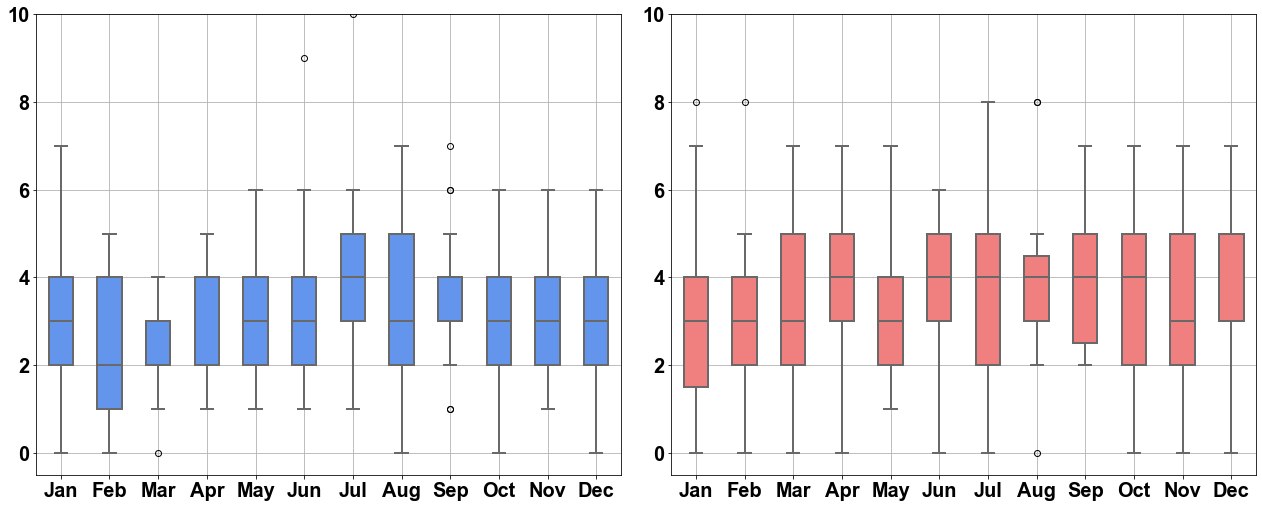

In [34]:


'BOX PLOT CYC ANTCYC'
p=plt.figure(figsize=(17.94,  7.46))
gs = gridspec.GridSpec(1,2)
ax1 = plt.subplot(gs[0,0])

cbp=plt.boxplot(Cbox.T,widths=0.5,patch_artist=True)

for box in cbp['boxes']:
    box.set(color='dimgray',linewidth=2)
    box.set(facecolor ='cornflowerblue')
    # box.set(hatch = '/')

plt.setp(cbp['whiskers'],color='dimgray',linewidth=2)
plt.setp(cbp['fliers'],color='dimgray',linewidth=2)
plt.setp(cbp['medians'],color='dimgray',linewidth=2)
plt.setp(cbp['caps'],color='dimgray',linewidth=2)

# for whisk in cbp
#     whisk.set(color='dimgray',linewidth=2)
#     # fly.set(color='k', linewidth=2,alpha=0.8)


plt.grid()
plt.xticks(ticks=np.arange(1,13),labels=mostr,fontsize=20)
plt.ylim(-0.5,10)


ax2 = plt.subplot(gs[0,1])

abp=plt.boxplot(Abox.T,widths=0.5,patch_artist=True)

for box in abp['boxes']:
    box.set(color='dimgray',linewidth=2)
    box.set(facecolor = 'lightcoral')
    # box.set(hatch = '/')

plt.setp(abp['whiskers'],color='dimgray',linewidth=2)
plt.setp(abp['fliers'],color='dimgray',linewidth=2)
plt.setp(abp['medians'],color='dimgray',linewidth=2)
plt.setp(abp['caps'],color='dimgray',linewidth=2)


plt.grid()
plt.xticks(ticks=np.arange(1,13),labels=mostr,fontsize=20)
plt.ylim(-0.5,10)

plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Boxplot_Month.png')
# plt.close()

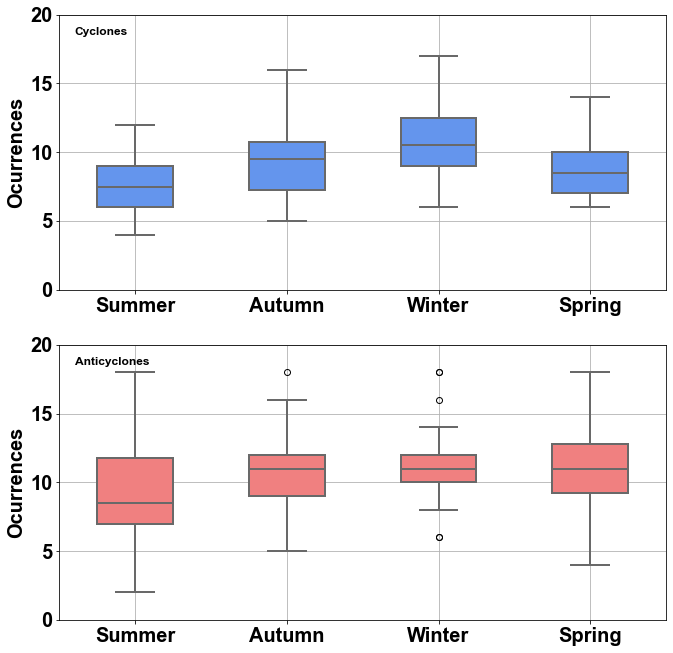

In [35]:

'BOX PLOT SEASONAL'
mosea=['Summer','Autumn','Winter','Spring']

CSazBox=np.zeros([4, np.abs(cyea.min()-cyea.max())+1])
ASazBox=np.zeros([4, np.abs(ayea.min()-ayea.max())+1])

'Verão'
ASazBox[0,:]=Abox.iloc[:3,:].sum(0) 
CSazBox[0,:]=Cbox.iloc[:3,:].sum(0) 

'Outono'
ASazBox[1,:]=Abox.iloc[3:6,:].sum(0) 
CSazBox[1,:]=Cbox.iloc[3:6,:].sum(0) 

'Inverno'
ASazBox[2,:]=Abox.iloc[6:9,:].sum(0) 
CSazBox[2,:]=Cbox.iloc[6:9,:].sum(0) 

'Primavera'
ASazBox[3,:]=Abox.iloc[9:,:].sum(0) 
CSazBox[3,:]=Cbox.iloc[9:,:].sum(0) 

ASazBox=pd.DataFrame(ASazBox,columns=range(1993,np.abs(cyea.min()-cyea.max())+1+1993))
CSazBox=pd.DataFrame(CSazBox,columns=range(1993,np.abs(ayea.min()-ayea.max())+1+1993))

ASazBox=ASazBox.iloc[:,:-1]
CSazBox=CSazBox.iloc[:,:-1]



p=plt.figure(figsize=(9.75, 9.47 ))
gs = gridspec.GridSpec(2,1)
ax1 = plt.subplot(gs[0,0])

cbp=plt.boxplot(CSazBox.T,widths=0.5,patch_artist=True)

for box in cbp['boxes']:
    box.set(color='dimgray',linewidth=2)
    box.set(facecolor ='cornflowerblue')
    # box.set(hatch = '/')

plt.setp(cbp['whiskers'],color='dimgray',linewidth=2)
plt.setp(cbp['fliers'],color='dimgray',linewidth=2)
plt.setp(cbp['medians'],color='dimgray',linewidth=2)
plt.setp(cbp['caps'],color='dimgray',linewidth=2)

plt.text(0.6,18.5,'Cyclones',fontsize=12)
plt.ylabel('Ocurrences',fontweight='bold')


plt.ylim(0,20)
plt.grid()
plt.xticks(ticks=np.arange(1,5),labels=mosea)
# plt.ylim(0,20)


ax2 = plt.subplot(gs[1,0])

abp=plt.boxplot(ASazBox.T,widths=0.5,patch_artist=True)

for box in abp['boxes']:
    box.set(color='dimgray',linewidth=2)
    box.set(facecolor = 'lightcoral')
    # box.set(hatch = '/')

plt.setp(abp['whiskers'],color='dimgray',linewidth=2)
plt.setp(abp['fliers'],color='dimgray',linewidth=2)
plt.setp(abp['medians'],color='dimgray',linewidth=2)
plt.setp(abp['caps'],color='dimgray',linewidth=2)

plt.text(0.6,18.5,'Anticyclones',fontsize=12)
plt.ylabel('Ocurrences',fontweight='bold')

plt.ylim(0,20)

plt.grid()
plt.xticks(ticks=np.arange(1,5),labels=mosea)
# plt.ylim(0,20)

plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Boxplot_Seasonal.png')
# plt.close()

### PDF Annual Frequency

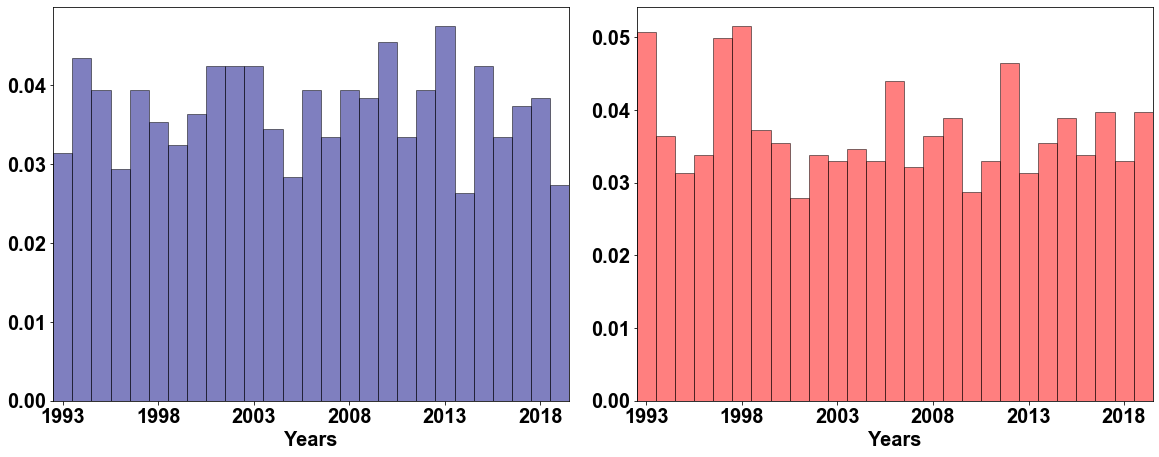

In [57]:



'PDF annual frequency'

p=plt.figure(figsize=(16.51,  6.75 ))
gs = gridspec.GridSpec(1,2)

ax1 = plt.subplot(gs[0, 0])

n=plt.hist(cyea,bins=yrange,color='navy',edgecolor='k',alpha=0.5,density=1)
# plt.plot(np.arange(cyea[0],cyea[-1]+1),n[0],'-',color='navy',alpha=1)
# sns.distplot(cyea,bins=yrange,color='navy',hist_kws={'edgecolor':'k'})
ax1.set_xlabel('Years',fontweight='bold')

ax1.set_xlim(cyea[0]-1,cyea[-1]+1)
# ax1.set_ylim(n[0].min()-5,n[0].max()+5)

ax1.set_xticks(np.arange(cyea[0],cyea[-1]+1)[::5])
ax1.set_xticklabels(np.arange(cyea[0],cyea[-1]+1)[::5])

plt.xlim(1992.5,2019.5)


ax2 = plt.subplot(gs[0, 1])

n=plt.hist(ayea,bins=yrange,color='red',edgecolor='k',alpha=0.5,density=1)
# plt.plot(np.arange(ayea[0],ayea[-1]+1),n[0],'-',color='red',alpha=1)

# sns.distplot(ayea,bins=yrange,color='red',hist_kws={'edgecolor':'k'})
ax2.set_xlabel('Years',fontweight='bold')

ax2.set_xlim(ayea[0]-1,ayea[-1]+1)
# ax2.set_ylim(n[0].min()-5,n[0].max()+5)

ax2.set_xticks(np.arange(ayea[0],ayea[-1]+1)[::5])
ax2.set_xticklabels(np.arange(ayea[0],ayea[-1]+1)[::5])
plt.xlim(1992.5,2019.5)

plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_frequency_anual.png')
# plt.close()



### PLotting Formation A+C,C,A Seasonal Fluctuation



### Setting cartopy map template

<ipython-input-82-3a3fc6f0ebc4>:39: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  atim=dt0 + timedelta(days=(np.int(np.min(Atime[atrack==ira]))));atim=atim.month;# minimo para pegar o primeiro dia
<ipython-input-59-7887f2b2a45a>:49: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes i

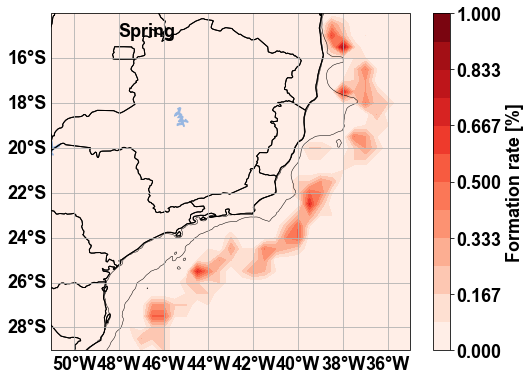

In [82]:
#test

ltmn=-29;ltmx=-14;lnmn=-51;lnmx=-35.

resol=0.5 #criando mapa de zeros para distribuição
lonf=np.arange(lnmn-2*resol,lnmx+resol,resol)
latf=np.arange(ltmn-2*resol,ltmx+resol,resol)

# lonf=np.arange(lnmn,lnmx+resol,resol)
# latf=np.arange(ltmn,ltmx+resol,resol)

# latf,lonf=np.meshgrid(latf,lonf)
lonf,latf=np.meshgrid(lonf,latf)

'Season setting'
# for ira in range(atrack.max()):
sea=[[1,2,3],
    [4,5,6],
    [7,8,9],
    [10,11,12]]

i=3
mon=sea[i]


acmap=np.zeros(lonf.shape);
ccmap=np.zeros(lonf.shape);


'''
FORMATION REGIONS
'''

for ira in aunik[acond]:

        # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
        # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100

    atim=dt0 + timedelta(days=(np.int(np.min(Atime[atrack==ira]))));atim=atim.month;# minimo para pegar o primeiro dia
    if (atim in mon):
        # if (arr>=40) & (app>=vamp) & (atim in mon):


        alx,aly=alon[atrack==ira][0],alat[atrack==ira][0]
        xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
        yind=np.argwhere(aly>=latf[:,0]).T[0][-1]


        acmap[yind,xind]+=1

        
AP=((acmap)/(anumber))*100
fig1(sizeh=8.06,sizev=6.19,lnmn=-51,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx,grid_a=1)

# plt.figure(figsize=(8.06,6.19))
plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)

# plt.pcolormesh(lonf,latf,((acmap)/(anumber))*100,cmap='Reds',vmin=0,vmax=3);
plt.contourf(lonf,latf,AP,levels=np.linspace(0,1,13),cmap='Reds');
plt.text(lonf.min()+4,latf.max()-1,'{0}'.format(mosea[i]))
cbar=plt.colorbar()
cbar.set_label('Formation rate [%]',fontweight='bold') 
# plt.ylim(-29,-14)
# plt.xlim(-55,-35)
# plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
# plt.title('N = {:d}'.format((np.int(np.sum(acmap)))))


In [87]:
ltmn=-29;ltmx=-14;lnmn=-51;lnmx=-35.



resol=1 #criando mapa de zeros para distribuição
lonf=np.arange(lnmn-2*resol,lnmx+resol,resol)
latf=np.arange(ltmn-2*resol,ltmx+resol,resol)

# latf,lonf=np.meshgrid(latf,lonf)
lonf,latf=np.meshgrid(lonf,latf)

'Season setting'
# for ira in range(atrack.max()):
sea=[[1,2,3],
    [4,5,6],
    [7,8,9],
    [10,11,12]]

# i=3
for i in range(4):
    mon=sea[i]


    acmap=np.zeros(lonf.shape);
    ccmap=np.zeros(lonf.shape);


    '''
    FORMATION REGIONS
    '''

    for ira in aunik[acond]:

            # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
            # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100
            
        atim=dt0 + timedelta(days=(np.int(np.min(Atime[atrack==ira]))));atim=atim.month;# minimo para pegar o primeiro dia
        if (atim in mon):
            # if (arr>=40) & (app>=vamp) & (atim in mon):


            alx,aly=alon[atrack==ira][0],alat[atrack==ira][0]
            xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
            yind=np.argwhere(aly>=latf[:,0]).T[0][-1]
        

            acmap[yind,xind]+=1

    # for irc in range(ctrack.max()):
    for irc in cunik[ccond]:
            # crr=np.mean(cnc['effective_radius'][:].data[ctrack==irc])/1e3
            # cpp=np.mean(cnc['amplitude'][:].data[ctrack==irc])*100
        ctim=dt0+ timedelta(days=(np.int(np.min(Ctime[ctrack==irc]))));ctim=ctim.month; # minimo para pegar o primeiro dia

        if (ctim in mon):

            clx,cly=clon[ctrack==irc][0],clat[ctrack==irc][0]
            xind=np.argwhere(clx>=lonf[0,:]).T[0][-1]
            yind=np.argwhere(cly>=latf[:,0]).T[0][-1]

            ccmap[yind,xind]+=1
    
    fig1(sizeh=8.06,sizev=6.19,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)
    plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
#     plt.pcolormesh(lonf,latf,((acmap+ ccmap)/(anumber + cnumber))*100,cmap=cm.cm.tempo,vmin=0,vmax=2.5);
    plt.contourf(lonf,latf,((acmap+ ccmap)/(anumber + cnumber))*100,levels=np.linspace(0,1,13),cmap=cm.cm.tempo);



    cbar=plt.colorbar()
    cbar.set_label('Formation {0} [%]'.format(mosea[i]),fontweight='bold') 

    plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)

    # plt.title('N = {:d}'.format((np.int(np.sum(ccmap + acmap)))))

#     plt.tight_layout()
    # plt.savefig('/home/igor/Documents/AntSimi/figures/Total_formation_season_{0}.png'.format(mosea[i]))
    plt.savefig('/Users/iufarias/Documents/META3.1exp/figs/Total_formation_season_{0}_modo1.png'.format(mosea[i]))
    plt.close()


    fig1(sizeh=8.06,sizev=6.19,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


    plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)

#     plt.pcolormesh(lonf,latf,((ccmap)/(cnumber))*100,cmap='Blues',vmin=0,vmax=2.5);
    plt.contourf(lonf,latf,((ccmap)/(cnumber))*100,cmap='Blues',levels=np.linspace(0,1.1,13))
    plt.text(lonf.min()+4,latf.max()-1,'{0}'.format(mosea[i]))

    cbar=plt.colorbar()
    cbar.set_label('Formation rate [%]',fontweight='bold') 

    plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
    # plt.title('N = {:d}'.format((np.int(np.sum(ccmap)))))

#     plt.tight_layout()
    # plt.savefig('/home/igor/Documents/AntSimi/figures/Cyclonic_birth_season_{0}.png'.format(mosea[i]))
    plt.savefig('/Users/iufarias/Documents/META3.1exp/figs/Cyclonic_birth_season_{0}_modo1.png'.format(mosea[i]))

    plt.close()



    fig1(sizeh=8.06,sizev=6.19,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


    plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)

#     plt.pcolormesh(lonf,latf,((acmap)/(anumber))*100,cmap='Reds',vmin=0,vmax=3);
    plt.contourf(lonf,latf,((acmap)/(anumber))*100,cmap='Reds',levels=np.linspace(0,1.1,13));
    plt.text(lonf.min()+4,latf.max()-1,'{0}'.format(mosea[i]))
    cbar=plt.colorbar()
    cbar.set_label('Formation rate [%]',fontweight='bold') 

    plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
    # plt.title('N = {:d}'.format((np.int(np.sum(acmap)))))


#     plt.tight_layout()
    # plt.savefig('/home/igor/Documents/AntSimi/figures/Anticyclonic_birth_season_{0}.png'.format(mosea[i]))
    plt.savefig('/Users/iufarias/Documents/META3.1exp/figs/Anticyclonic_birth_season_{0}_modo1.png'.format(mosea[i]))
    plt.close()




<ipython-input-87-a9e23e816e53>:37: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  atim=dt0 + timedelta(days=(np.int(np.min(Atime[atrack==ira]))));atim=atim.month;# minimo para pegar o primeiro dia
<ipython-input-87-a9e23e816e53>:53: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check

### Figures 4 - Heatmaps of Dissipation, Formation, etc

<ipython-input-59-7887f2b2a45a>:49: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())


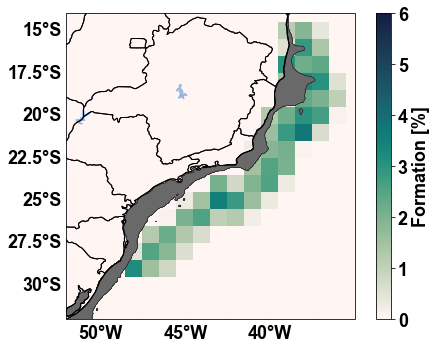

In [88]:
ltmn=-32;ltmx=-14;lnmn=-52;lnmx=-35.

resol=1
lonf=np.arange(lnmn-6*resol,lnmx+resol,resol)
latf=np.arange(ltmn-6*resol,ltmx+resol,resol)

# latf,lonf=np.meshgrid(latf,lonf)
lonf,latf=np.meshgrid(lonf,latf)

acmap=np.zeros(lonf.shape);
ccmap=np.zeros(lonf.shape);



'''
FORMATION REGIONS
'''
# for ira in range(atrack.max()):
for ira in aunik[acond]:

        # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
        # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100

        # if (arr>=40) & (app>=vamp):
        alx,aly=alon[atrack==ira][0],alat[atrack==ira][0]
        xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
        yind=np.argwhere(aly>=latf[:,0]).T[0][-1]


        acmap[yind,xind]+=1

# for irc in range(ctrack.max()):
for irc in cunik[ccond]:
        # crr=np.mean(cnc['effective_radius'][:].data[ctrack==irc])/1e3
        # cpp=np.mean(cnc['amplitude'][:].data[ctrack==irc])*100

        # if (crr>=40) & (cpp>=vamp):
        clx,cly=clon[ctrack==irc][0],clat[ctrack==irc][0]
        xind=np.argwhere(clx>=lonf[0,:]).T[0][-1]
        yind=np.argwhere(cly>=latf[:,0]).T[0][-1]

        ccmap[yind,xind]+=1


fig1(sizeh=8.06,sizev=6.19,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)

plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
# C.contourf(lonf,latf,((acmap+ ccmap)/np.nanmax(acmap + ccmap))*100,cmap='YlGnBu_r',latlon=True,levels=np.linspace(0,60,35))
# plt.pcolormesh(lonf,latf,((acmap+ ccmap)/np.nanmax(acmap + ccmap))*100,cmap=cm.cm.tempo,vmin=0,vmax=80);
plt.pcolormesh(lonf,latf,((acmap+ ccmap)/(anumber + cnumber))*100,cmap=cm.cm.tempo,vmin=0,vmax=6);

cbar=plt.colorbar()
cbar.set_label('Formation [%]',fontweight='bold') 

plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)


plt.tight_layout()
# plt.savefig('/home/igor/Documents/AntSimi/figures/Total_formation.png')
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_formation_modo2.png')

# plt.close()

### Dissipation

In [89]:

acdmap=np.zeros(lonf.shape);
ccdmap=np.zeros(lonf.shape);


# for ira in range(atrack.max()):
for ira in aunik[acond]:

        # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
        # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100

        # if (arr>=40) & (app>=vamp):

    alx,aly=alon[atrack==ira][-1],alat[atrack==ira][-1]
    xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(aly>=latf[:,0]).T[0][-1]

    acdmap[yind,xind]+=1

# for irc in range(ctrack.max()):
for irc in cunik[ccond]:
        # crr=np.mean(cnc['effective_radius'][:].data[ctrack==irc])/1e3
        # cpp=np.mean(cnc['amplitude'][:].data[ctrack==irc])*100

        # if (crr>=40) & (cpp>=vamp):
    clx,cly=clon[ctrack==irc][-1],clat[ctrack==irc][-1]
    xind=np.argwhere(clx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(cly>=latf[:,0]).T[0][-1]

    ccdmap[yind,xind]+=1


fig1(sizeh=8.06,sizev=6.19,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)

plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
# C.contourf(lonf,latf,(acdmap + ccdmap)/np.nanmax(acdmap + ccdmap)*100,cmap='YlGnBu_r',latlon=True,levels=np.linspace(0,60,35))
# plt.pcolormesh(lonf,latf,((acdmap+ ccdmap)/np.nanmax(acdmap + ccdmap))*100,cmap=cm.cm.tempo,vmin=0,vmax=80);
plt.pcolormesh(lonf,latf,((acdmap+ ccdmap)/(anumber + cnumber))*100,cmap=cm.cm.tempo,vmin=0,vmax=5);

cbar=plt.colorbar()
cbar.set_label('Dissipation [%]',fontweight='bold') 
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_dissipation_modo2.png')
# plt.close()



IndexError: index -1 is out of bounds for axis 0 with size 0

### Polarity Birth Map

<ipython-input-95-946917073ea3>:49: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())


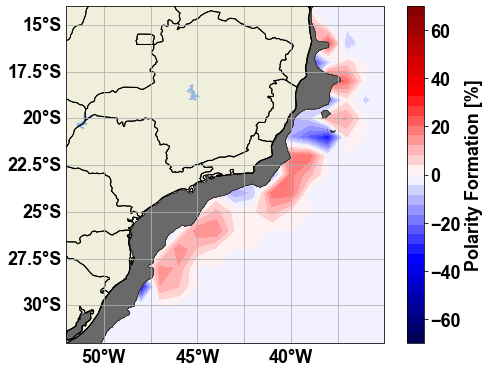

In [104]:
'BOTH'
fig1(sizeh=8.06,sizev=6.19,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx,grid_a=1)


plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,200],linewidths=0.5,latlon=True)
# # C.contourf(lonf,latf,(acmap - ccmap)/np.nanmax(abs(acmap - ccmap))*100,cmap='seismic',latlon=True,levels=np.linspace(-100,100,35))
plt.contourf(lonf,latf,((acmap - ccmap)/np.sum(acmap-ccmap))*100,cmap='seismic',latlon=True,levels=np.linspace(-70,70,35),zorder=-1)

# # plt.pcolormesh(lonf,latf,((acmap - ccmap)/np.nanmax(acmap - ccmap))*100,cmap='seismic',vmin=-100,vmax=100);

cbar=plt.colorbar(ticks=np.arange(-100,120,20))
cbar.set_label('Polarity Formation [%]',fontweight='bold')

plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-200,0],latlon=True)
# plt.tight_layout()
# plt.savefig('/Users/iufarias/Documents/META3.1exp/figs/Total_polarity_birth_modo2.png')
# plt.close()




<ipython-input-139-7045362eb542>:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())


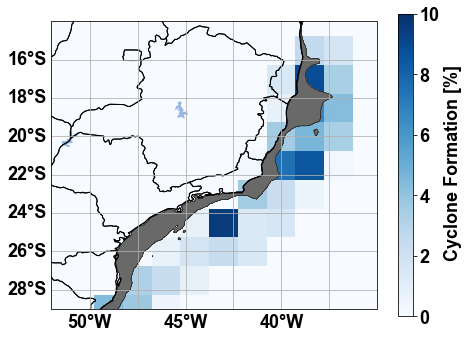

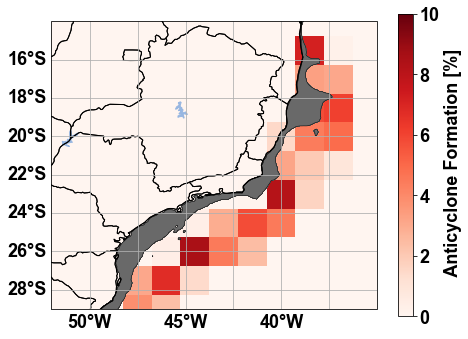

In [152]:

'CYCLONES'
fig1(sizeh=8.06,sizev=6.19,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)

plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
# C.contourf(lonf,latf,(acmap - ccmap)/np.nanmax(abs(acmap - ccmap))*100,cmap='seismic',latlon=True,levels=np.linspace(-100,100,35))
# plt.pcolormesh(lonf,latf,((ccmap)/np.nanmax(ccmap))*100,cmap='Blues',vmin=0,vmax=80);
plt.pcolormesh(lonf,latf,((ccmap)/cnumber)*100,cmap='Blues',vmin=0,vmax=10);


cbar=plt.colorbar()
cbar.set_label(' Cyclone Formation [%]',fontweight='bold')

plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/cyclonic_birth.png')
# plt.close()


'ANTICYCLONES'
fig1(sizeh=8.06,sizev=6.19,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)

plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
# C.contourf(lonf,latf,(acmap - ccmap)/np.nanmax(abs(acmap - ccmap))*100,cmap='seismic',latlon=True,levels=np.linspace(-100,100,35))
plt.pcolormesh(lonf,latf,((acmap)/anumber)*100,cmap='Reds',vmin=0,vmax=10);

cbar=plt.colorbar()
cbar.set_label(' Anticyclone Formation [%]',fontweight='bold')

plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/anticyclonic_birth.png')
# plt.close()

### Swirling Speed

<ipython-input-154-2b69f62ffeac>:38: RuntimeWarning: invalid value encountered in true_divide
  Velp=np.nanmean(((velmap)/dummy),axis=1)
<ipython-input-154-2b69f62ffeac>:38: RuntimeWarning: Mean of empty slice
  Velp=np.nanmean(((velmap)/dummy),axis=1)
<ipython-input-154-2b69f62ffeac>:39: RuntimeWarning: invalid value encountered in true_divide
  Velpstd=np.nanstd(((velmap)/dummy),axis=1)
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1664: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<ipython-input-139-7045362eb542>:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCar

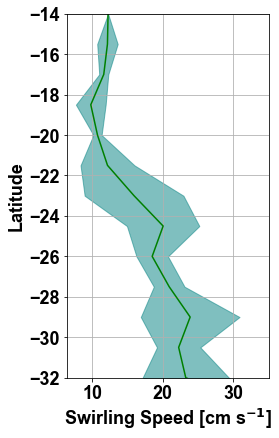

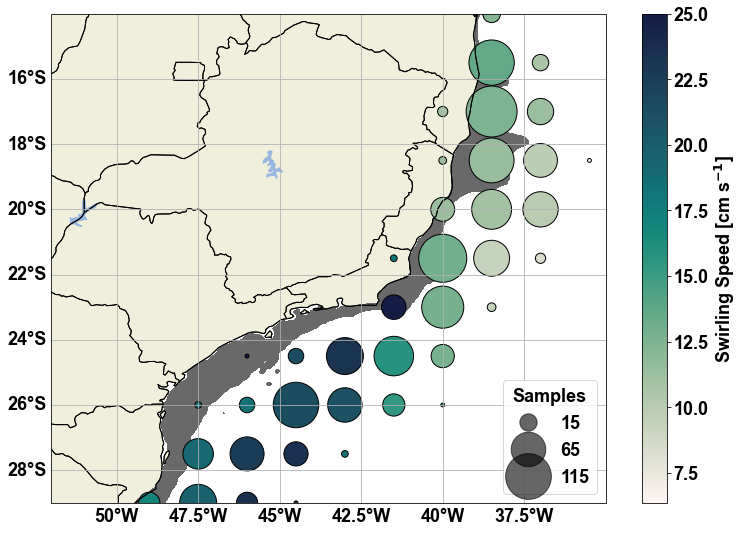

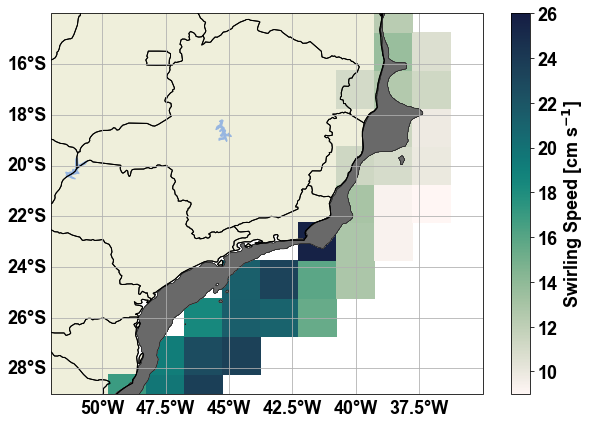

In [154]:

velmap=np.zeros(lonf.shape);
adummy=np.zeros(lonf.shape);
cdummy=np.zeros(lonf.shape);


# for ira in range(atrack.max()):
for ira in aunik[acond]:
        # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
        # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100

        # if (arr>=40) & (app>=vamp):

    alx,aly=np.mean(alon[atrack==ira]),np.mean(alat[atrack==ira])

    xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(aly>=latf[:,0]).T[0][-1]

    adummy[yind,xind]+=1
    velmap[yind,xind]+=Avel[ira]*100


# for irc in range(ctrack.max()):
for irc in cunik[ccond]:
        # crr=np.mean(cnc['effective_radius'][:].data[ctrack==irc])/1e3
        # cpp=np.mean(cnc['amplitude'][:].data[ctrack==irc])*100

        # if (crr>=40) & (cpp>=vamp):

    clx,cly=np.mean(clon[ctrack==irc]),np.mean(clat[ctrack==irc])
    xind=np.argwhere(clx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(cly>=latf[:,0]).T[0][-1]

    cdummy[yind,xind]+=1
    velmap[yind,xind]+=Cvel[irc]*100

dummy=adummy+cdummy

Velp=np.nanmean(((velmap)/dummy),axis=1)
Velpstd=np.nanstd(((velmap)/dummy),axis=1)

ps=plt.figure(figsize=(4.18, 6.43))
plt.plot(Velp,latf[:,0],color='green')
plt.fill_betweenx(x1=Velp-Velpstd,x2=Velp+Velpstd,y=latf[:,0],color='teal',alpha=0.5) 
plt.grid()
plt.xlabel('Swirling Speed [cm s$^{-1}$]',fontweight='bold')
plt.ylabel('Latitude',fontweight='bold')
plt.ylim(-32,-14)

# 'Latitudes'
# plt.plot([Velpstd.min(),Velpstd.max()],[-20,-20],'k--')



plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Profile_Total_velocity.png')
# plt.close()


cafac=15

fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)

# C.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)

# plt.pcolormesh(lonf,latf,((velmap)/(dummy)),cmap=cm.cm.tempo,vmin=9,vmax=26);
axx=plt.scatter(lonf,latf,c=((velmap)/(dummy)),s=dummy*scafac,cmap=cm.cm.tempo,edgecolors='k',vmax=25)


handles, labels = axx.legend_elements(prop="sizes", alpha=0.6)
plt.legend(handles[::3],['15','65','115'], loc="lower right", title="Samples") 

cbar=plt.colorbar()
cbar.set_label('Swirling Speed [cm s$^{-1}$]',fontweight='bold') 

plt.tight_layout()

# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/SCattermap_Total_velocity.png')
# plt.close()



dummy[dummy<5]=0
velmap[dummy<5]=0

fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)
plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
# C.contourf(lonf,latf,(radmap)/(adummy+cdummy),cmap='rainbow',extend='both',latlon=True,levels=np.linspace(40,130,35))
# plt.pcolormesh(lonf,latf,(radmap)/(adummy+cdummy),cmap='rainbow',vmin=40,vmax=130);
plt.pcolormesh(lonf,latf,((velmap)/(dummy)),cmap=cm.cm.tempo,vmin=9,vmax=26);

cbar=plt.colorbar()
cbar.set_label('Swirling Speed [cm s$^{-1}$]',fontweight='bold') 
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
plt.tight_layout()

# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_velocity.png')
# plt.close()




### Radius map

<ipython-input-158-f68d35064eca>:42: RuntimeWarning: invalid value encountered in true_divide
  Radp=np.nanmean(((radmap)/dummy),axis=1)
<ipython-input-158-f68d35064eca>:42: RuntimeWarning: Mean of empty slice
  Radp=np.nanmean(((radmap)/dummy),axis=1)
<ipython-input-158-f68d35064eca>:43: RuntimeWarning: invalid value encountered in true_divide
  Radpstd=np.nanstd(((radmap)/dummy),axis=1)
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1664: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<ipython-input-139-7045362eb542>:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCar

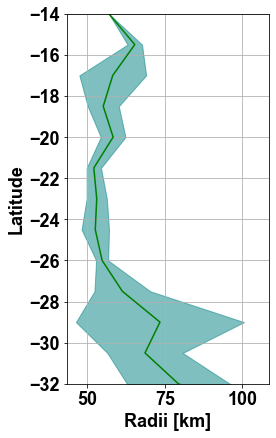

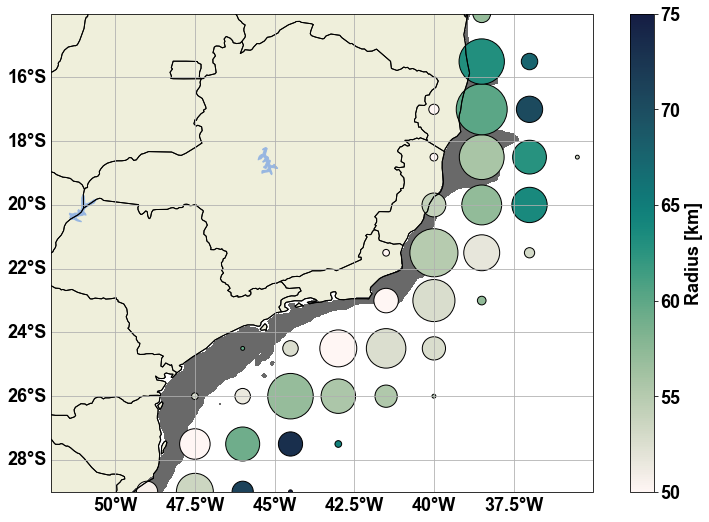

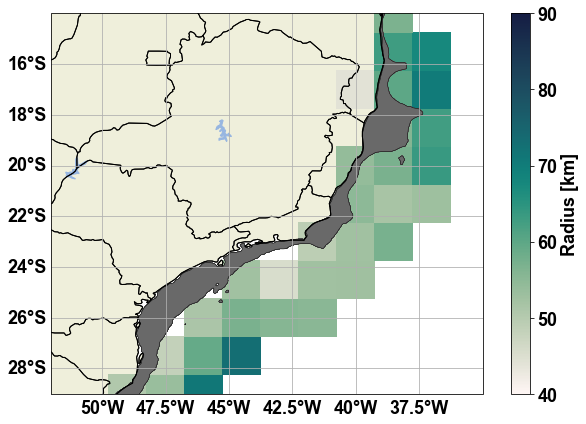

In [158]:


radmap=np.zeros(lonf.shape);
adummy=np.zeros(lonf.shape);
cdummy=np.zeros(lonf.shape);


# for ira in range(atrack.max()):
for ira in aunik[acond]:
        # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
        # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100

        # if (arr>=40) & (app>=vamp):


    alx,aly=np.mean(alon[atrack==ira]),np.mean(alat[atrack==ira])

    xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(aly>=latf[:,0]).T[0][-1]

    adummy[yind,xind]+=1
    radmap[yind,xind]+=Arad[ira]/1e3


# for irc in range(ctrack.max()):
for irc in cunik[ccond]:
        # crr=np.mean(cnc['effective_radius'][:].data[ctrack==irc])/1e3
        # cpp=np.mean(cnc['amplitude'][:].data[ctrack==irc])*100

        # if (crr>=40) & (cpp>=vamp):

    clx,cly=np.mean(clon[ctrack==irc]),np.mean(clat[ctrack==irc])
    xind=np.argwhere(clx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(cly>=latf[:,0]).T[0][-1]

    cdummy[yind,xind]+=1
    radmap[yind,xind]+=Crad[irc]/1e3


dummy=adummy+cdummy



Radp=np.nanmean(((radmap)/dummy),axis=1)
Radpstd=np.nanstd(((radmap)/dummy),axis=1)

ps=plt.figure(figsize=(4.18, 6.43))
plt.plot(Radp,latf[:,0],color='green')
plt.fill_betweenx(x1=Radp-Radpstd,x2=Radp+Radpstd,y=latf[:,0],color='teal',alpha=0.5) 
plt.grid()
plt.xlabel('Radii [km]',fontweight='bold')
plt.ylabel('Latitude',fontweight='bold')
plt.ylim(-32,-14)

# 'Latitudes'
# plt.plot([Velpstd.min(),Velpstd.max()],[-20,-20],'k--')



plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Profile_Total_radii.png')
# plt.close()




'Scatter MAP'
fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


# C.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)

# plt.pcolormesh(lonf,latf,((velmap)/(dummy)),cmap=cm.cm.tempo,vmin=9,vmax=26);
plt.scatter(lonf,latf,c=((radmap)/(dummy)),s=dummy*scafac,vmin=50,vmax=75,cmap=cm.cm.tempo,edgecolors='k')

cbar=plt.colorbar()
cbar.set_label('Radius [km]',fontweight='bold') 

plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/SCattermap_Total_radius.png')
# plt.close()


dummy[dummy<5]=0
radmap[dummy<5]=0

fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
# C.contourf(lonf,latf,(radmap)/(adummy+cdummy),cmap='rainbow',extend='both',latlon=True,levels=np.linspace(40,130,35))
# plt.pcolormesh(lonf,latf,(radmap)/(adummy+cdummy),cmap='rainbow',vmin=40,vmax=130);
plt.pcolormesh(lonf,latf,((radmap)/(dummy)),cmap=cm.cm.tempo,vmin=40,vmax=90);

cbar=plt.colorbar()
cbar.set_label('Radius [km]',fontweight='bold') 
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
plt.tight_layout()

# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_radius.png')
# plt.close()





### Amplitude

<ipython-input-159-b78c1720e4d0>:43: RuntimeWarning: invalid value encountered in true_divide
  Ampp=np.nanmean(((ampmap)/dummy),axis=1)
<ipython-input-159-b78c1720e4d0>:43: RuntimeWarning: Mean of empty slice
  Ampp=np.nanmean(((ampmap)/dummy),axis=1)
<ipython-input-159-b78c1720e4d0>:44: RuntimeWarning: invalid value encountered in true_divide
  Amppstd=np.nanstd(((ampmap)/dummy),axis=1)
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1664: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<ipython-input-139-7045362eb542>:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCar

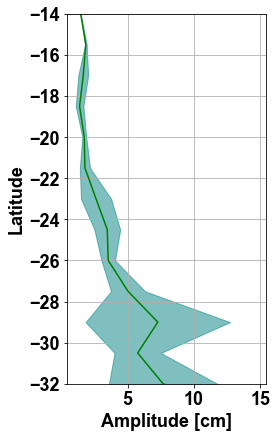

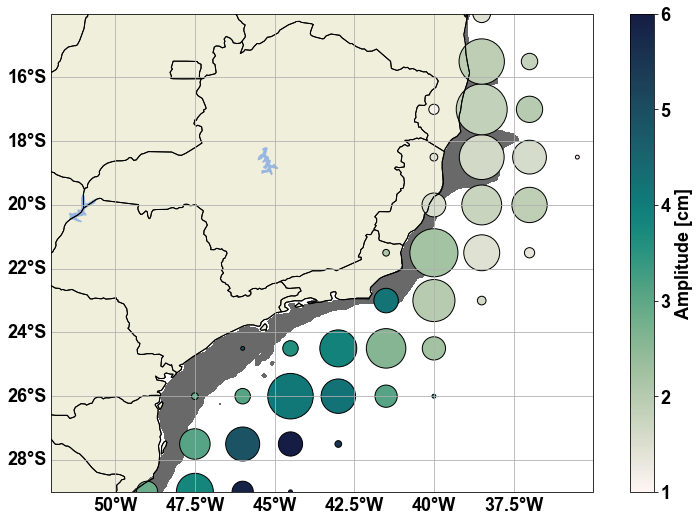

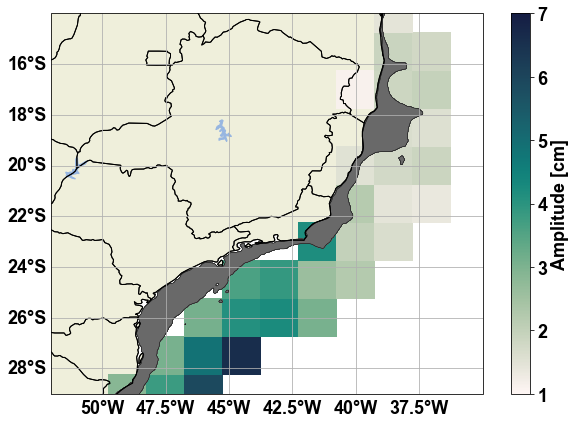

In [159]:


ampmap=np.zeros(lonf.shape);
adummy=np.zeros(lonf.shape);
cdummy=np.zeros(lonf.shape);


# for ira in range(atrack.max()):
for ira in aunik[acond]:
        # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
        # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100

        # if (arr>=40) & (app>=vamp):

    alx,aly=np.mean(alon[atrack==ira]),np.mean(alat[atrack==ira])

    xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(aly>=latf[:,0]).T[0][-1]

    adummy[yind,xind]+=1
    ampmap[yind,xind]+=Aamp[ira]*100


# for irc in range(ctrack.max()):
for irc in cunik[ccond]:
        # crr=np.mean(cnc['effective_radius'][:].data[ctrack==irc])/1e3
        # cpp=np.mean(cnc['amplitude'][:].data[ctrack==irc])*100

        # if (crr>=40) & (cpp>=vamp):

    clx,cly=np.mean(clon[ctrack==irc]),np.mean(clat[ctrack==irc])
    xind=np.argwhere(clx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(cly>=latf[:,0]).T[0][-1]

    cdummy[yind,xind]+=1
    ampmap[yind,xind]+=Camp[irc]*100




dummy=adummy+cdummy



Ampp=np.nanmean(((ampmap)/dummy),axis=1)
Amppstd=np.nanstd(((ampmap)/dummy),axis=1)

ps=plt.figure(figsize=(4.18, 6.43))
plt.plot(Ampp,latf[:,0],color='green')
plt.fill_betweenx(x1=Ampp-Amppstd,x2=Ampp+Amppstd,y=latf[:,0],color='teal',alpha=0.5) 
plt.grid()
plt.xlabel('Amplitude [cm]',fontweight='bold')
plt.ylabel('Latitude',fontweight='bold')
plt.ylim(-32,-14)

# 'Latitudes'
# plt.plot([Velpstd.min(),Velpstd.max()],[-20,-20],'k--')



plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Profile_Total_amplitude.png')
# plt.close()



'Scatter MAP'
fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


# C.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)

# plt.pcolormesh(lonf,latf,((velmap)/(dummy)),cmap=cm.cm.tempo,vmin=9,vmax=26);
plt.scatter(lonf,latf,c=((ampmap)/(dummy)),s=dummy*scafac,cmap=cm.cm.tempo,edgecolors='k',vmin=1,vmax=6)

cbar=plt.colorbar()
cbar.set_label('Amplitude [cm]',fontweight='bold') 

plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/SCattermap_Total_amplitude.png')
# plt.close()


dummy[dummy<5]=0
ampmap[dummy<5]=0

fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
# C.contourf(lonf,latf,(ampmap)/(adummy+cdummy),cmap='rainbow',extend='both',latlon=True,levels=np.linspace(vamp,10,35))
plt.pcolormesh(lonf,latf,(ampmap)/(dummy),cmap=cm.cm.tempo,vmin=1,vmax=7);

cbar=plt.colorbar()
cbar.set_label('Amplitude [cm]',fontweight='bold') 
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
plt.tight_layout()

# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_amplitude.png')
# plt.close()

### Non-linearity Maps

<ipython-input-160-96be603f915c>:51: RuntimeWarning: invalid value encountered in true_divide
  Nlp=np.nanmean(((nlmap)/dummy),axis=1)
<ipython-input-160-96be603f915c>:51: RuntimeWarning: Mean of empty slice
  Nlp=np.nanmean(((nlmap)/dummy),axis=1)
<ipython-input-160-96be603f915c>:52: RuntimeWarning: invalid value encountered in true_divide
  Nlpstd=np.nanstd(((nlmap)/dummy),axis=1)
/Users/iufarias/opt/anaconda3/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1664: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<ipython-input-139-7045362eb542>:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())

NameError: name 'C' is not defined

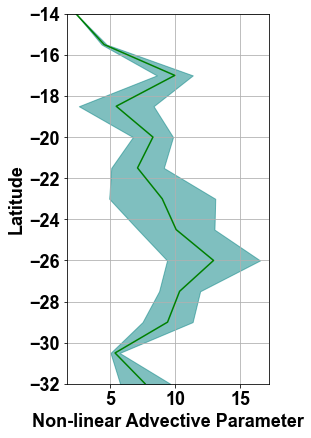

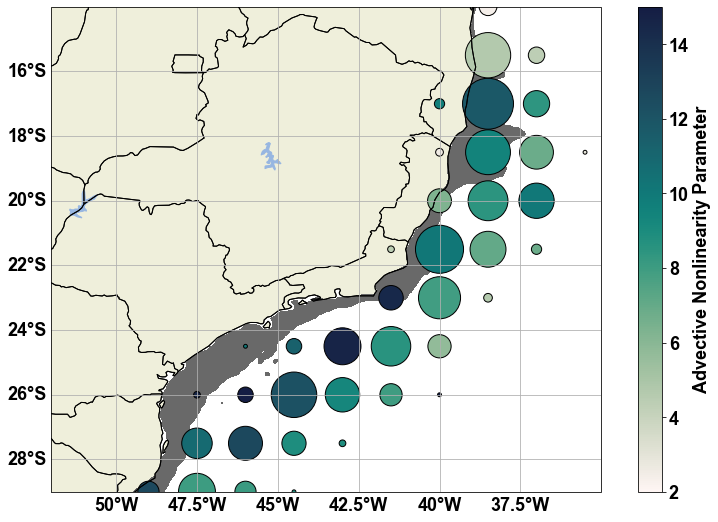

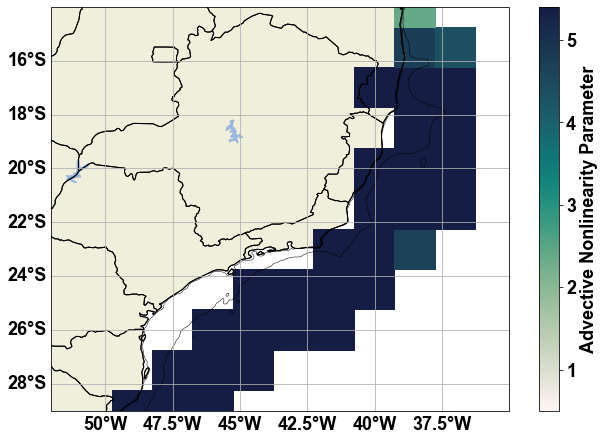

In [160]:


nlmap=np.zeros(lonf.shape);
adummy=np.zeros(lonf.shape);
cdummy=np.zeros(lonf.shape);


# for ira in range(atrack.max()):
i=0
for ira in aunik[acond]:
        # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
        # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100

        # if (arr>=40) & (app>=vamp):

    alx,aly=np.mean(alon[atrack==ira]),np.mean(alat[atrack==ira])

    xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(aly>=latf[:,0]).T[0][-1]

    adummy[yind,xind]+=1
    # nlmap[yind,xind]+= (np.nanmax(anc['speed_average'][:][atrack==ira])  /  (Apvel[i]))
    nlmap[yind,xind]+= (Avelmax[ira]/ (Apvel2[i]/100))

    i+=1

i=0
# for irc in range(ctrack.max()):
for irc in cunik[ccond]:
    # crr=np.mean(cnc['effective_radius'][:].data[ctrack==irc])/1e3
    # cpp=np.mean(cnc['amplitude'][:].data[ctrack==irc])*100

    # if (crr>=40) & (cpp>=vamp):

    clx,cly=np.mean(clon[ctrack==irc]),np.mean(clat[ctrack==irc])

    xind=np.argwhere(clx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(cly>=latf[:,0]).T[0][-1]

    cdummy[yind,xind]+=1
    # nlmap[yind,xind]+=(np.nanmax(cnc['speed_average'][:][ctrack==irc])/(Cpvel[i]))
    nlmap[yind,xind]+=(Cvelmax[irc]/(Cpvel2[i]/100))

    
    i+=1



dummy=adummy+cdummy



Nlp=np.nanmean(((nlmap)/dummy),axis=1)
Nlpstd=np.nanstd(((nlmap)/dummy),axis=1)

ps=plt.figure(figsize=(4.18, 6.43))
plt.plot(Nlp,latf[:,0],color='green')
plt.fill_betweenx(x1=Nlp-Nlpstd,x2=Nlp+Nlpstd,y=latf[:,0],color='teal',alpha=0.5) 
plt.grid()
plt.xlabel('Non-linear Advective Parameter',fontweight='bold')
plt.ylabel('Latitude',fontweight='bold')
plt.ylim(-32,-14)

# 'Latitudes'
# plt.plot([Velpstd.min(),Velpstd.max()],[-20,-20],'k--')



plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Profile_Total_nonlinear.png')
# plt.close()




'Scatter MAP'
fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


# C.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)

# plt.pcolormesh(lonf,latf,((velmap)/(dummy)),cmap=cm.cm.tempo,vmin=9,vmax=26);
plt.scatter(lonf,latf,c=((nlmap)/(dummy)),s=dummy*scafac,cmap=cm.cm.tempo,edgecolors='k',vmin=2,vmax=15)

cbar=plt.colorbar()
cbar.set_label('Advective Nonlinearity Parameter',fontweight='bold') 

plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/SCattermap_Total_nonlinear.png')
# plt.close()


dummy[dummy<5]=0
nlmap[dummy<5]=0

fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


plt.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
# C.contourf(lonf,latf,(nlmap)/(adummy+cdummy),cmap='rainbow',extend='both',latlon=True,levels=np.linspace(0,6,35))
plt.pcolormesh(lonf,latf,(nlmap)/(dummy),cmap=cm.cm.tempo,vmin=0.5,vmax=5.4);

cbar=plt.colorbar()
cbar.set_label('Advective Nonlinearity Parameter',fontweight='bold') 
C.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)
plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/Total_nonlinear.png')
# plt.close()








### Duration

<ipython-input-139-7045362eb542>:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.axes(projection=ccrs.PlateCarree())
<ipython-input-162-7a7cffc6a1c5>:56: RuntimeWarning: invalid value encountered in true_divide
  plt.scatter(lonf,latf,c=((durmap)/(dummy)),s=dummy*scafac,cmap=cm.cm.tempo,edgecolors='k',vmin=15,vmax=90)


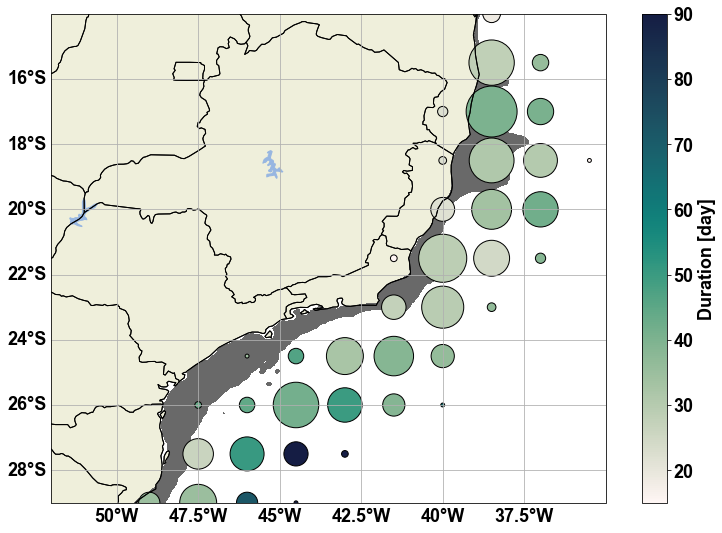

In [162]:

durmap=np.zeros(lonf.shape);
adummy=np.zeros(lonf.shape);
cdummy=np.zeros(lonf.shape);


# for ira in range(atrack.max()):
i=0
for ira in aunik[acond]:
    # arr=np.mean(anc['effective_radius'][:].data[atrack==ira])/1e3
    # app=np.mean(anc['amplitude'][:].data[atrack==ira])*100

    # if (arr>=40) & (app>=vamp):

    alx,aly=np.mean(alon[atrack==ira]),np.mean(alat[atrack==ira])

    xind=np.argwhere(alx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(aly>=latf[:,0]).T[0][-1]

    adummy[yind,xind]+=1
    # nlmap[yind,xind]+= (np.nanmax(anc['speed_average'][:][atrack==ira])  /  (Apvel[i]))
    durmap[yind,xind]+= len(atrack[atrack==ira])

    i+=1

i=0
# for irc in range(ctrack.max()):
for irc in cunik[ccond]:
    # crr=np.mean(cnc['effective_radius'][:].data[ctrack==irc])/1e3
    # cpp=np.mean(cnc['amplitude'][:].data[ctrack==irc])*100

    # if (crr>=40) & (cpp>=vamp):

    clx,cly=np.mean(clon[ctrack==irc]),np.mean(clat[ctrack==irc])

    xind=np.argwhere(clx>=lonf[0,:]).T[0][-1]
    yind=np.argwhere(cly>=latf[:,0]).T[0][-1]

    cdummy[yind,xind]+=1
    # nlmap[yind,xind]+=(np.nanmax(cnc['speed_average'][:][ctrack==irc])/(Cpvel[i]))
    durmap[yind,xind]+=len(ctrack[ctrack==irc])
    
    i+=1



dummy=adummy+cdummy


fig1(sizeh=10.65,sizev=7.43,lnmn=lnmn,lnmx=lnmx,ltmn=ltmn,ltmx=ltmx)


# C.contour(xxb,yyb,-zb,colors='k',alpha=1,levels=[0,100],linewidths=0.5,latlon=True)
plt.contourf(xxb,yyb,zb,colors='dimgray',alpha=1,levels=[-100,0],latlon=True)

# plt.pcolormesh(lonf,latf,((velmap)/(dummy)),cmap=cm.cm.tempo,vmin=9,vmax=26);
plt.scatter(lonf,latf,c=((durmap)/(dummy)),s=dummy*scafac,cmap=cm.cm.tempo,edgecolors='k',vmin=15,vmax=90)

cbar=plt.colorbar()
cbar.set_label('Duration [day]',fontweight='bold') 

plt.tight_layout()
# plt.savefig('/home/igor/Dropbox/META_eddydetection_images/SCattermap_Total_duration.png')
# plt.close()